# 15 perces varoskoncepció -- Budapest, Google Maps Timeline

## Elemzési pipeline

| Fázis | Leírás |
|-------|--------|
| 1. Adatbetöltés és tisztítás | MySQL → időszűrés → Budapest térbeli szűrés → minőségellenőrzés |
| 2. Referencia-helyszínek | A4 binned clustering (Verma et al. 2024) → home/work → 2×2 mátrix |
| 3. POI adatbázis | OpenStreetMap → Moreno 5 kategória → georeferált POI-k |
| 4. Izokrón és elérhetőség | ORS API → 15 perces gyalogos/kerékpáros izokrón → POI spatial join |
| 5. Lokalizációs index | Stay point detektálás → LI = belső/összes stay point |
| 6. Statisztikai elemzés | Szociodemográfiai bontás, korreláció, klaszterezés |
| 7. Vizualizáció | KDE, hőtérkép, dashboard, export |


In [92]:
# ============================================================================
# IMPORTOK ÉS GLOBÁLIS KONFIGURÁCIÓ
# ============================================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
import json
import time
import requests
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2

from shapely.geometry import Point, shape, mapping
from shapely.ops import unary_union
from pyproj import Transformer
from sklearn.cluster import MeanShift, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.stats import mannwhitneyu, kruskal, spearmanr
from scipy.ndimage import gaussian_filter

import mysql.connector
import mysql.connector.errors as mysql_connector_errors

try:
    import osmnx as ox
except ImportError:
    print("WARNING: osmnx not installed. POI fetch will not work.")

try:
    import hdbscan
except ImportError:
    print("INFO: hdbscan not installed. HDBSCAN clustering will be skipped.")

# ---------- Konstansok -------------------------------------------------------
NIGHTTIME_START = 19   # éjszakai ablak kezdete (19:00)
NIGHTTIME_END   = 7    # éjszakai ablak vége (07:00)
WORKTIME_START  = 8    # munkahelyi ablak kezdete (08:00)
WORKTIME_END    = 17   # munkahelyi ablak vége (17:00)
BIN_DURATION_MIN = 30  # A4 binnelés időablak (perc)
BANDWIDTH_M     = 250  # Mean-Shift kernel sugár (m)
MIN_NIGHT_PINGS = 10   # minimális éjszakai pingek száma
HOME_WORK_MIN_DIST_M = 250  # home-work átfedési küszöb (m)
BOOTSTRAP_B     = 1000 # bootstrap iterációk száma
WALK_SPEED_KMH  = 5    # gyalogos sebesség
BIKE_SPEED_KMH  = 15   # kerékpáros sebesség
ISOCHRONE_SECONDS = 900 # 15 perc

# ORS API (https://openrouteservice.org/ -- regisztráció szükséges)
ORS_API_KEY = "eyJvcmciOiI1YjNjZTM1OTc4NTExMTAwMDFjZjYyNDgiLCJpZCI6IjMwMWZhMTljYjllMTRiMjdhNTFkZTA4NGM2MTYyOGI1IiwiaCI6Im11cm11cjY0In0="  # <-- IDE ÍRD A SAJÁT KULCSODAT
ORS_BASE_URL = "https://api.openrouteservice.org/v2/isochrones"

# Fájl cache könyvtár
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

# Stay point paraméterek
STAY_MERGE_DIST_M = 200  # összevonási sugár (m)
STAY_MIN_DURATION_MIN = 1  # minimális tartózkodási idő (perc)

# DB beállítások
HOST = '172.20.1.2'
PORT = 3306
USER = 'pnaday'
PASS = "nWn1DQzvhMtdgijzSC6x"
DATABASE = 'data_donation_prod_sensitive'

print("Konfiguráció betöltve.")
print(f"  Éjszakai ablak: {NIGHTTIME_START}:00 – {NIGHTTIME_END}:00")
print(f"  Munkahelyi ablak: {WORKTIME_START}:00 – {WORKTIME_END}:00 (hétköznap)")
print(f"  A4 bin méret: {BIN_DURATION_MIN} perc")
print(f"  Mean-Shift bandwidth: {BANDWIDTH_M} m")
print(f"  Bootstrap B: {BOOTSTRAP_B}")


Konfiguráció betöltve.
  Éjszakai ablak: 19:00 – 7:00
  Munkahelyi ablak: 8:00 – 17:00 (hétköznap)
  A4 bin méret: 30 perc
  Mean-Shift bandwidth: 250 m
  Bootstrap B: 1000


In [93]:
# ============================================================================
# FÁZIS 1.1: ADATBÁZIS CSATLAKOZÁS
# ============================================================================

def mysql_connect(host, port, username, password, database):
    """Connect to a MySQL database with the given parameters."""
    try:
        cnx = mysql.connector.connect(
            host=host,
            port=port,
            user=username,
            password=password,
            database=database,
            charset="utf8mb4",
            collation="utf8mb4_unicode_ci"
        )
        print(f'Successfully connected to MySQL server at {host}:{port}, database: {database}')
        cur = cnx.cursor(dictionary=True)
    except mysql_connector_errors.DatabaseError:
        print(f'Cannot connect to MySQL server at {host}:{port}, database: {database}')
        raise
    return cnx, cur

try:
    con, cur = mysql_connect(host=HOST, port=PORT, username=USER, password=PASS, database=DATABASE)
    cur.execute('SELECT respondent_id, location_lat, location_lng, duration_startTimestamp, duration_endTimestamp, center_lat, center_lng FROM `google_location_history_place_visits`;')
    data = cur.fetchall()
    df_raw = pd.DataFrame(data)
    con.close()
    print(f"Adatok letöltve: {len(df_raw):,} rekord, {df_raw['respondent_id'].nunique():,} résztvevő")
    print(f"\nOszlopok: {list(df_raw.columns)}")
    print(df_raw.head(3))
except Exception as e:
    print(f"HIBA: {e}")
    df_raw = None

Successfully connected to MySQL server at 172.20.1.2:3306, database: data_donation_prod_sensitive
Adatok letöltve: 1,535,658 rekord, 394 résztvevő

Oszlopok: ['respondent_id', 'location_lat', 'location_lng', 'duration_startTimestamp', 'duration_endTimestamp', 'center_lat', 'center_lng']
   respondent_id location_lat location_lng duration_startTimestamp  \
0          20145  47.50850700  19.07196650     2011-12-29 20:20:04   
1          20145  47.50850700  19.07196650     2011-12-29 21:30:46   
2          20145  47.50850700  19.07196650     2011-12-30 16:33:18   

  duration_endTimestamp   center_lat   center_lng  
0   2011-12-29 20:39:09  47.50901500  19.07251250  
1   2011-12-30 07:47:43  47.50893360  19.07246200  
2   2011-12-30 23:15:04  47.50885110  19.07245500  


In [94]:
# ============================================================================
# FÁZIS 1.2: IDŐABLAK SZŰRÉS (2018-06-18 – 2023-06-18)
# ============================================================================

if df_raw is not None:
    DATE_END = pd.Timestamp('2023-06-18')
    DATE_START = DATE_END - pd.DateOffset(years=5)

    print(f'Időszak: {DATE_START.date()} – {DATE_END.date()}')
    print(f'Rekordok szűrés előtt: {len(df_raw):,}')

    df_raw['duration_startTimestamp'] = pd.to_datetime(df_raw['duration_startTimestamp'])
    df_raw['duration_endTimestamp'] = pd.to_datetime(df_raw['duration_endTimestamp'])

    df = df_raw[
        (df_raw['duration_startTimestamp'] >= DATE_START) &
        (df_raw['duration_startTimestamp'] <= DATE_END)
    ].copy()

    # Számított mezők
    df['duration_hours'] = (
        df['duration_endTimestamp'] - df['duration_startTimestamp']
    ).dt.total_seconds() / 3600
    df['start_hour'] = df['duration_startTimestamp'].dt.hour
    df['day_of_week'] = df['duration_startTimestamp'].dt.dayofweek  # 0=Monday

    print(f'Rekordok szűrés után:  {len(df):,}')
    print(f'Érintett résztvevők:   {df["respondent_id"].nunique():,}')
else:
    print("Nincs adat — a szerver nem elérhető.")
    df = None


Időszak: 2018-06-18 – 2023-06-18
Rekordok szűrés előtt: 1,535,658
Rekordok szűrés után:  1,180,014
Érintett résztvevők:   394


In [95]:
# ============================================================================
# FÁZIS 1.3: ADATMINŐSÉGI SZŰRÉS
# ============================================================================

def haversine_m(lat1, lng1, lat2, lng2):
    """Haversine távolság méterben két WGS84 pont között."""
    R = 6_371_000
    dlat = radians(lat2 - lat1)
    dlng = radians(lng2 - lng1)
    a = sin(dlat / 2) ** 2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlng / 2) ** 2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

if df is not None:
    n_before = len(df)

    # Koordináták numerikussá alakítása
    df['location_lat'] = pd.to_numeric(df['location_lat'], errors='coerce')
    df['location_lng'] = pd.to_numeric(df['location_lng'], errors='coerce')

    # 1) Null/nulla koordináták eltávolítása
    mask_null = df['location_lat'].isna() | df['location_lng'].isna()
    mask_zero = (df['location_lat'] == 0) & (df['location_lng'] == 0)
    df = df[~mask_null & ~mask_zero].copy()
    n_after_null = len(df)
    print(f"Null/nulla koordináták eltávolítva: {n_before - n_after_null:,}")

    # 2) Teleportáció-szűrő: sebességalapú (egymás utáni rekordok között)
    df = df.sort_values(['respondent_id', 'duration_startTimestamp']).reset_index(drop=True)
    df['prev_lat'] = df.groupby('respondent_id')['location_lat'].shift(1)
    df['prev_lng'] = df.groupby('respondent_id')['location_lng'].shift(1)
    df['prev_end'] = df.groupby('respondent_id')['duration_endTimestamp'].shift(1)

    # Csak ahol van előző rekord (nem az első)
    has_prev = df['prev_lat'].notna()
    df.loc[has_prev, 'dist_m'] = df[has_prev].apply(
        lambda r: haversine_m(r['prev_lat'], r['prev_lng'], r['location_lat'], r['location_lng']),
        axis=1
    )
    df.loc[has_prev, 'time_diff_s'] = (
        df.loc[has_prev, 'duration_startTimestamp'] - df.loc[has_prev, 'prev_end']
    ).dt.total_seconds()

    # Sebesség: dist / time (ahol time > 0)
    valid_speed = has_prev & (df['time_diff_s'] > 0)
    df.loc[valid_speed, 'speed_ms'] = df.loc[valid_speed, 'dist_m'] / df.loc[valid_speed, 'time_diff_s']

    # > 50 m/s (180 km/h) -> teleportáció, kizárás
    mask_teleport = df['speed_ms'] > 50
    n_teleport = mask_teleport.sum()
    df = df[~mask_teleport].copy()
    print(f"Teleportáció (>50 m/s) eltávolítva: {n_teleport:,}")

    # Ideiglenes oszlopok törlése
    df = df.drop(columns=['prev_lat', 'prev_lng', 'prev_end', 'dist_m', 'time_diff_s', 'speed_ms'],
                 errors='ignore')

    # 3) Negatív tartózkodási idők eltávolítása (>24 h szűrő eltávolítva)
    mask_neg = df['duration_hours'] < 0
    df = df[~mask_neg].copy()
    print(f"Negatív tartózkodás eltávolítva: {mask_neg.sum():,}")

    print(f"\nÖsszes rekord szűrés után: {len(df):,} (eltávolítva: {n_before - len(df):,})")
    print(f"Résztvevők: {df['respondent_id'].nunique():,}")
else:
    print("Nincs adat.")


Null/nulla koordináták eltávolítva: 2,697
Teleportáció (>50 m/s) eltávolítva: 2,877
Negatív tartózkodás eltávolítva: 0

Összes rekord szűrés után: 1,174,440 (eltávolítva: 5,574)
Résztvevők: 394


In [96]:
# ============================================================================
# FÁZIS 1.4: BUDAPEST TÉRBELI SZŰRÉS
# ============================================================================
if df is not None:
    # Budapest közigazgatási határ lekérése
    budapest = ox.geocode_to_gdf('Budapest, Hungary')
    budapest_boundary = budapest.geometry.iloc[0]

    # GeoDataFrame létrehozás
    geometry = [Point(lng, lat) for lng, lat in zip(df['location_lng'], df['location_lat'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')

    # Spatial filter
    points_in_city = gdf[gdf.within(budapest_boundary)].copy()

    # Tisztán térbeli Budapest-szűrő — elmentjük a night-ping szűrés előtt
    budapest_respondents = set(points_in_city['respondent_id'].unique())

    print(f"Budapest-en belüli rekordok: {len(points_in_city):,} "
          f"({len(points_in_city)/len(df)*100:.1f}%)")
    print(f"Résztvevők Budapest-en belül: {points_in_city['respondent_id'].nunique():,}")
else:
    points_in_city = None
    print("Nincs adat.")

Budapest-en belüli rekordok: 314,103 (26.7%)
Résztvevők Budapest-en belül: 311


In [97]:
# ============================================================================
# FÁZIS 1.5: RÉSZTVEVŐ-SZINTŰ MINŐSÉGELLENŐRZÉS
# ============================================================================

if points_in_city is not None:
    # Éjszakai pingek (19:00-07:00) száma résztvevőnként
    night_mask = (
        (points_in_city['start_hour'] >= NIGHTTIME_START) |
        (points_in_city['start_hour'] < NIGHTTIME_END)
    )
    night_counts = points_in_city[night_mask].groupby('respondent_id').size()

    # Kizárás: < MIN_NIGHT_PINGS éjszakai ping
    valid_respondents = night_counts[night_counts >= MIN_NIGHT_PINGS].index
    excluded = points_in_city['respondent_id'].nunique() - len(valid_respondents)

    points_in_city = points_in_city[
        points_in_city['respondent_id'].isin(valid_respondents)
    ].copy()

    print(f"Éjszakai ping minimum ({MIN_NIGHT_PINGS}): {excluded} résztvevő kizárva")
    print(f"Megmaradt résztvevők: {len(valid_respondents):,}")

    # Megfigyelési periódus és adatsűrűség
    resp_stats = points_in_city.groupby('respondent_id').agg(
        n_records=('duration_startTimestamp', 'count'),
        first_record=('duration_startTimestamp', 'min'),
        last_record=('duration_startTimestamp', 'max')
    )
    resp_stats['obs_days'] = (resp_stats['last_record'] - resp_stats['first_record']).dt.days + 1
    resp_stats['records_per_day'] = resp_stats['n_records'] / resp_stats['obs_days']

    print(f"\nAdatsűrűség statisztikák:")
    print(f"  Rekordok/fő: medián={resp_stats['n_records'].median():.0f}, "
          f"IQR=[{resp_stats['n_records'].quantile(0.25):.0f}, {resp_stats['n_records'].quantile(0.75):.0f}]")
    print(f"  Megfigyelési napok: medián={resp_stats['obs_days'].median():.0f}")
    print(f"  Rekord/nap: medián={resp_stats['records_per_day'].median():.1f}")
else:
    print("Nincs adat.")


Éjszakai ping minimum (10): 163 résztvevő kizárva
Megmaradt résztvevők: 148

Adatsűrűség statisztikák:
  Rekordok/fő: medián=1002, IQR=[290, 3602]
  Megfigyelési napok: medián=1616
  Rekord/nap: medián=1.1


## Fázis 2: Referencia-helyszínek azonosítása

### A4 Binned Clustering (Verma et al. 2024)

Az A4 algoritmus az éjszakai/nappali pingeket 30 perces időbinekre bontja, binnenkénti centroidot számít,
majd a centroidokon Mean-Shift klaszterezést futtat. Ez a módszer kiküszöböli a navigáció közbeni
tömör pingcsoportok okozta torzítást.

**Lépések:**
1. Éjszakai (19:00-07:00) vagy hétköznap nappali (08:00-17:00) szűrés
2. 30 perces időbinekre bontás → bin-centroid számítás
3. Mean-Shift klaszterezés (250m bandwidth) a bin-centroidokon
4. Lakóhely/munkahely = legnagyobb klaszter centroidja

**2×2 klasszifikáció:**
- **HT-WT**: mindkét helyszín megbízhatóan azonosítható
- **HT-WnT**: lakóhely azonosítható, munkahely nem (home office, diák, nyugdíjas)
- **HnT-WT**: munkahely azonosítható, lakóhely nem
- **HnT-WnT**: egyik sem azonosítható


In [98]:
# ============================================================================
# FÁZIS 2.1: HELPER FÜGGVÉNYEK
# ============================================================================

def create_time_bins(pings_df, bin_duration_min=BIN_DURATION_MIN):
    """
    Éjszakai/nappali pingek 30 perces binekre bontása.
    Minden binből egyetlen centroidot számít (A4 kulcslépés).

    Returns: DataFrame bin-centroidokkal (lat, lng, bin_id)
    """
    if len(pings_df) == 0:
        return pd.DataFrame(columns=['lat', 'lng', 'bin_id'])

    df = pings_df.copy()
    df = df.sort_values('duration_startTimestamp')

    # Bin-index: epoch perc / bin_duration
    df['epoch_min'] = (
        df['duration_startTimestamp'].astype(np.int64) // 10**9 // 60
    )
    df['bin_id'] = df['epoch_min'] // bin_duration_min

    # Centroid per bin (üres binek kiesnek)
    bin_centroids = df.groupby('bin_id').agg(
        lat=('location_lat', 'mean'),
        lng=('location_lng', 'mean'),
        n_pings=('location_lat', 'count')
    ).reset_index()

    return bin_centroids


def mean_shift_detect(coords_df, bandwidth_m=BANDWIDTH_M):
    """
    Mean-Shift klaszterezés koordinátákon.
    coords_df: DataFrame 'lat', 'lng' oszlopokkal.
    Returns: (largest_cluster_centroid_lat, largest_cluster_centroid_lng, n_clusters, n_points)
    """
    coords = coords_df[['lat', 'lng']].values
    if len(coords) < 2:
        return coords[0, 0], coords[0, 1], 1, len(coords)

    # Bandwidth: méterből fokba (~111 km/fok)
    bw_deg = bandwidth_m / 111_000

    try:
        ms = MeanShift(bandwidth=bw_deg, bin_seeding=False, n_jobs=1)
        ms.fit(coords)
        labels = ms.labels_
        centroids = ms.cluster_centers_

        unique, counts = np.unique(labels, return_counts=True)
        best_idx = unique[np.argmax(counts)]
        best_centroid = centroids[best_idx]

        return best_centroid[0], best_centroid[1], len(unique), len(coords)
    except Exception:
        # Fallback: egyszerű átlag
        return coords[:, 0].mean(), coords[:, 1].mean(), 1, len(coords)


def detect_location_a4(pings_df, bin_duration_min=BIN_DURATION_MIN, bandwidth_m=BANDWIDTH_M):
    """
    A4 Binned Clustering: binelés → centroidok → Mean-Shift.
    Returns: dict {lat, lng, n_bins, n_clusters, n_pings}
    """
    bin_centroids = create_time_bins(pings_df, bin_duration_min)

    if len(bin_centroids) == 0:
        return None

    lat, lng, n_clusters, n_points = mean_shift_detect(bin_centroids, bandwidth_m)

    return {
        'lat': lat,
        'lng': lng,
        'n_bins': len(bin_centroids),
        'n_clusters': n_clusters,
        'n_pings': len(pings_df)
    }


def detect_location_a3(pings_df, bandwidth_m=BANDWIDTH_M):
    """
    A3 Mean-Shift: közvetlen klaszterezés a nyers pingeken (összehasonlításhoz).
    Returns: dict {lat, lng, n_clusters, n_pings}
    """
    if len(pings_df) < 2:
        if len(pings_df) == 1:
            return {'lat': pings_df.iloc[0]['location_lat'],
                    'lng': pings_df.iloc[0]['location_lng'],
                    'n_clusters': 1, 'n_pings': 1}
        return None

    coords = pings_df[['location_lat', 'location_lng']].rename(
        columns={'location_lat': 'lat', 'location_lng': 'lng'})
    lat, lng, n_clusters, n_points = mean_shift_detect(coords, bandwidth_m)

    return {'lat': lat, 'lng': lng, 'n_clusters': n_clusters, 'n_pings': len(pings_df)}

print("Helper függvények betöltve.")


Helper függvények betöltve.


In [99]:
# ============================================================================
# FÁZIS 2.2: LAKÓHELY (HOME) DETEKTÁLÁS – A4 BINNED CLUSTERING
# ============================================================================

if points_in_city is not None:
    # Éjszakai szűrés: 19:00–07:00 (dolgozat specifikáció)
    night_pings = points_in_city[
        (points_in_city['start_hour'] >= NIGHTTIME_START) |
        (points_in_city['start_hour'] < NIGHTTIME_END)
    ].copy()

    print(f"Éjszakai pingek (19:00-07:00): {len(night_pings):,}")
    print(f"Résztvevők éjszakai adattal: {night_pings['respondent_id'].nunique():,}")

    # --- A4: Binned Clustering ---
    home_results_a4 = []
    for resp_id, grp in night_pings.groupby('respondent_id'):
        result = detect_location_a4(grp)
        if result is not None:
            result['respondent_id'] = resp_id
            result['method'] = 'A4'
            home_results_a4.append(result)

    home_a4 = pd.DataFrame(home_results_a4)
    home_a4 = home_a4.rename(columns={'lat': 'home_lat', 'lng': 'home_lng'})

    # --- A3: Közvetlen Mean-Shift (összehasonlításhoz) ---
    home_results_a3 = []
    for resp_id, grp in night_pings.groupby('respondent_id'):
        result = detect_location_a3(grp)
        if result is not None:
            result['respondent_id'] = resp_id
            result['method'] = 'A3'
            home_results_a3.append(result)

    home_a3 = pd.DataFrame(home_results_a3)
    home_a3 = home_a3.rename(columns={'lat': 'home_lat', 'lng': 'home_lng'})

    # A4-et használjuk elsődlegesen
    home_locations = home_a4[['respondent_id', 'home_lat', 'home_lng', 'n_bins', 'n_clusters', 'n_pings']].copy()

    print(f"\nA4 – lakóhely detektálva: {len(home_a4)} résztvevő")
    print(f"A3 – lakóhely detektálva: {len(home_a3)} résztvevő (összehasonlításhoz)")

    # A3 vs A4 eltérés
    comparison = home_a4.merge(home_a3, on='respondent_id', suffixes=('_a4', '_a3'))
    comparison['dist_m'] = comparison.apply(
        lambda r: haversine_m(r['home_lat_a4'], r['home_lng_a4'],
                              r['home_lat_a3'], r['home_lng_a3']), axis=1)
    print(f"\nA3 vs A4 eltérés: medián={comparison['dist_m'].median():.0f} m, "
          f"átlag={comparison['dist_m'].mean():.0f} m")
else:
    print("Nincs adat.")
    home_locations = None


Éjszakai pingek (19:00-07:00): 60,242
Résztvevők éjszakai adattal: 148

A4 – lakóhely detektálva: 148 résztvevő
A3 – lakóhely detektálva: 148 résztvevő (összehasonlításhoz)

A3 vs A4 eltérés: medián=600 m, átlag=1846 m


In [100]:
# ============================================================================
# FÁZIS 2.3: MUNKAHELY (WORK) DETEKTÁLÁS – A4 BINNED CLUSTERING
# ============================================================================

if points_in_city is not None:
    # Hétköznap nappali szűrés: 08:00–17:00, hétfő-péntek
    work_pings = points_in_city[
        (points_in_city['start_hour'] >= WORKTIME_START) &
        (points_in_city['start_hour'] < WORKTIME_END) &
        (points_in_city['day_of_week'].isin([0, 1, 2, 3, 4]))  # Mon-Fri
    ].copy()

    print(f"Nappali hétköznapi pingek (08:00-17:00, H-P): {len(work_pings):,}")
    print(f"Résztvevők: {work_pings['respondent_id'].nunique():,}")

    # A4: Binned Clustering a munkahelyre
    work_results = []
    for resp_id, grp in work_pings.groupby('respondent_id'):
        result = detect_location_a4(grp)
        if result is not None:
            result['respondent_id'] = resp_id
            work_results.append(result)

    work_locations = pd.DataFrame(work_results)
    work_locations = work_locations.rename(columns={'lat': 'work_lat', 'lng': 'work_lng'})

    # Home-work átfedés ellenőrzés
    if home_locations is not None and len(work_locations) > 0:
        hw_merged = home_locations.merge(work_locations, on='respondent_id', suffixes=('_h', '_w'))
        hw_merged['hw_dist_m'] = hw_merged.apply(
            lambda r: haversine_m(r['home_lat'], r['home_lng'],
                                  r['work_lat'], r['work_lng']), axis=1)

        # < 250m -> home office, munkahely nem azonosított
        home_office_mask = hw_merged['hw_dist_m'] < HOME_WORK_MIN_DIST_M
        home_office_ids = hw_merged.loc[home_office_mask, 'respondent_id'].values

        work_locations = work_locations[
            ~work_locations['respondent_id'].isin(home_office_ids)
        ].copy()

        print(f"\nHome-work átfedés (<{HOME_WORK_MIN_DIST_M}m, home office): "
              f"{len(home_office_ids)} résztvevő kizárva a munkahelydetektálásból")

    work_locations = work_locations[
        ['respondent_id', 'work_lat', 'work_lng', 'n_bins', 'n_clusters', 'n_pings']
    ].copy()
    print(f"Munkahely detektálva: {len(work_locations)} résztvevő")
else:
    print("Nincs adat.")
    work_locations = None


Nappali hétköznapi pingek (08:00-17:00, H-P): 154,870
Résztvevők: 148

Home-work átfedés (<250m, home office): 23 résztvevő kizárva a munkahelydetektálásból
Munkahely detektálva: 125 résztvevő


In [101]:
# ============================================================================
# FÁZIS 2.4: BOOTSTRAP KONFIDENCIAINTERVALLUM ÉS 2×2 KLASSZIFIKÁCIÓ
# ============================================================================

def bootstrap_location_ci(pings_df, n_bootstrap=BOOTSTRAP_B, bin_duration_min=BIN_DURATION_MIN,
                          bandwidth_m=BANDWIDTH_M, ci_level=0.95):
    """
    Bootstrap CI a detektált helyszínre.
    Visszatevéses újramintavétel a bin-centroid szintjén, B alkalommal.
    Returns: dict {lat_mean, lng_mean, ci_radius_m, is_reliable}
    """
    bin_centroids = create_time_bins(pings_df, bin_duration_min)
    if len(bin_centroids) < 3:
        return {'ci_radius_m': np.inf, 'is_reliable': False}

    boot_lats = []
    boot_lngs = []
    n = len(bin_centroids)

    for _ in range(n_bootstrap):
        # Visszatevéses újramintavétel a bin-centroidokból
        sample = bin_centroids.sample(n=n, replace=True)
        lat, lng, _, _ = mean_shift_detect(sample, bandwidth_m)
        boot_lats.append(lat)
        boot_lngs.append(lng)

    boot_lats = np.array(boot_lats)
    boot_lngs = np.array(boot_lngs)

    # Medián referenciapont
    ref_lat = np.median(boot_lats)
    ref_lng = np.median(boot_lngs)

    # Bootstrap távolságok a mediántól
    dists = np.array([haversine_m(ref_lat, ref_lng, lat, lng)
                      for lat, lng in zip(boot_lats, boot_lngs)])

    # 95. percentilis sugár
    ci_radius = np.percentile(dists, ci_level * 100)

    # Megbízható, ha a 95% CI sugár < 500m
    return {
        'ci_radius_m': ci_radius,
        'is_reliable': ci_radius < 500
    }

if points_in_city is not None and home_locations is not None:
    print("Bootstrap CI számítás lakóhelyekre...")
    print(f"(B={BOOTSTRAP_B}, ez eltarthat néhány percig {len(home_locations)} résztvevőre)")

    home_ci = []
    for i, (resp_id, grp) in enumerate(night_pings.groupby('respondent_id')):
        if resp_id not in home_locations['respondent_id'].values:
            continue
        ci = bootstrap_location_ci(grp)
        ci['respondent_id'] = resp_id
        home_ci.append(ci)
        if (i + 1) % 50 == 0:
            print(f"  {i+1}/{len(home_locations)} kész...")

    home_ci_df = pd.DataFrame(home_ci)

    # Home megbízhatóság
    home_reliable = set(home_ci_df[home_ci_df['is_reliable']]['respondent_id'])
    home_unreliable = set(home_ci_df[~home_ci_df['is_reliable']]['respondent_id'])

    print(f"\nLakóhely megbízható (HT): {len(home_reliable)}")
    print(f"Lakóhely nem megbízható (HnT): {len(home_unreliable)}")
    print(f"CI sugár medián: {home_ci_df['ci_radius_m'].median():.0f} m")

    # Work megbízhatóság (egyszerűsített: ha munkahely detektálva, azt WT-nek vesszük)
    work_ids = set(work_locations['respondent_id']) if work_locations is not None else set()
    all_resp_ids = set(home_locations['respondent_id'])

    # 2×2 mátrix
    classification = []
    for resp_id in all_resp_ids:
        ht = resp_id in home_reliable
        wt = resp_id in work_ids
        cat = f"{'HT' if ht else 'HnT'}-{'WT' if wt else 'WnT'}"
        classification.append({
            'respondent_id': resp_id,
            'home_reliable': ht,
            'work_detected': wt,
            'category': cat
        })

    participant_classification = pd.DataFrame(classification)

    # Kontingencia-tábla
    print("\n2×2 KLASSZIFIKÁCIÓS MÁTRIX:")
    print("=" * 50)
    ct = pd.crosstab(
        participant_classification['home_reliable'].map({True: 'HT', False: 'HnT'}),
        participant_classification['work_detected'].map({True: 'WT', False: 'WnT'}),
        margins=True
    )
    print(ct)
    print("=" * 50)

    # Kategória-eloszlás
    print("\nKategória-eloszlás:")
    for cat, count in participant_classification['category'].value_counts().items():
        pct = count / len(participant_classification) * 100
        print(f"  {cat}: {count} ({pct:.1f}%)")
else:
    participant_classification = None
    print("Nincs adat a bootstrap-hoz.")


Bootstrap CI számítás lakóhelyekre...
(B=1000, ez eltarthat néhány percig 148 résztvevőre)
  50/148 kész...
  100/148 kész...

Lakóhely megbízható (HT): 33
Lakóhely nem megbízható (HnT): 115
CI sugár medián: 2360 m

2×2 KLASSZIFIKÁCIÓS MÁTRIX:
work_detected   WT  WnT  All
home_reliable               
HT              21   12   33
HnT            104   11  115
All            125   23  148

Kategória-eloszlás:
  HnT-WT: 104 (70.3%)
  HT-WT: 21 (14.2%)
  HT-WnT: 12 (8.1%)
  HnT-WnT: 11 (7.4%)


In [72]:
# ============================================================================
# FÁZIS 2.5: HOME/WORK EGYESÍTÉS ÉS SZŰRÉS
# ============================================================================

if home_locations is not None and participant_classification is not None:
    # Merge home + work + classification
    home_work_df = home_locations[['respondent_id', 'home_lat', 'home_lng']].copy()

    if work_locations is not None and len(work_locations) > 0:
        home_work_df = home_work_df.merge(
            work_locations[['respondent_id', 'work_lat', 'work_lng']],
            on='respondent_id', how='left'
        )
    else:
        home_work_df['work_lat'] = np.nan
        home_work_df['work_lng'] = np.nan

    home_work_df = home_work_df.merge(participant_classification, on='respondent_id')

    # Csak HT résztvevők az izokrón-elemzéshez
    ht_respondents = home_work_df[home_work_df['home_reliable']]['respondent_id'].values
    points_for_analysis = points_in_city[
        points_in_city['respondent_id'].isin(ht_respondents)
    ].copy()

    print(f"HT résztvevők (izokrón-elemzésbe bevonhatók): {len(ht_respondents)}")
    print(f"Rekordok az elemzéshez: {len(points_for_analysis):,}")

    print(f"\nhome_work_df minta:")
    print(home_work_df.head())
else:
    home_work_df = None
    points_for_analysis = None
    print("Nincs adat.")


HT résztvevők (izokrón-elemzésbe bevonhatók): 33
Rekordok az elemzéshez: 81,144

home_work_df minta:
   respondent_id   home_lat   home_lng   work_lat   work_lng  home_reliable  \
0          20145  47.502244  19.043418  47.504487  19.046254          False   
1          20377  47.491942  19.074187  47.505898  19.060392          False   
2          26713  47.530981  19.059082  47.528686  19.059359           True   
3          34268  47.500263  19.065357  47.500283  19.024740          False   
4          58206  47.500031  19.021754        NaN        NaN           True   

   work_detected category  
0           True   HnT-WT  
1           True   HnT-WT  
2           True    HT-WT  
3           True   HnT-WT  
4          False   HT-WnT  


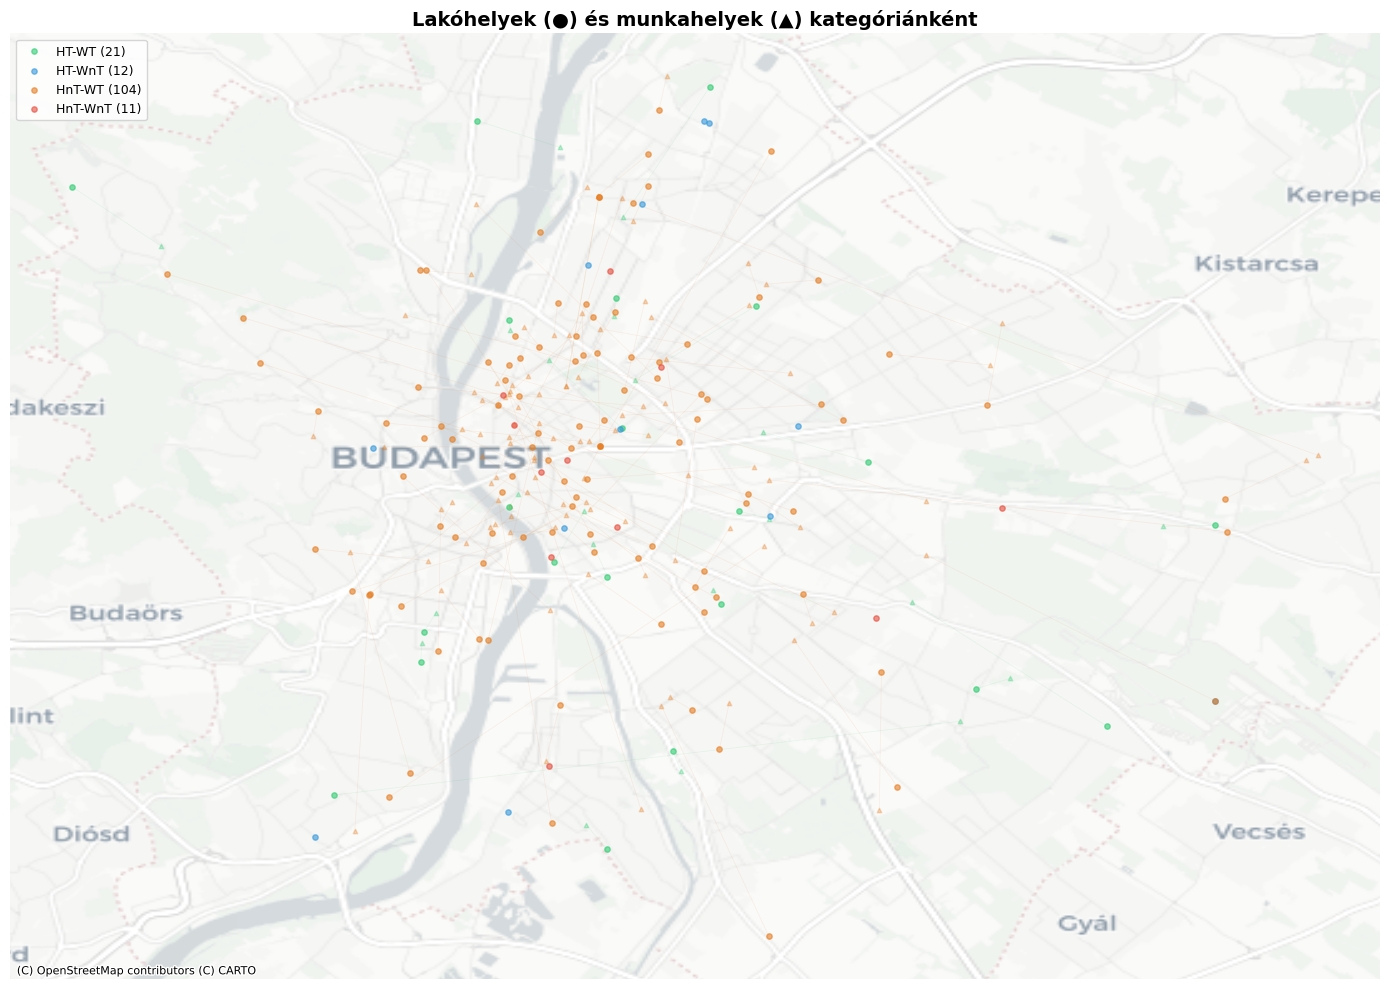

Térkép mentve: home_work_map.png


In [102]:
# ============================================================================
# FÁZIS 2.6: HOME/WORK VIZUALIZÁCIÓ
# ============================================================================

if home_work_df is not None:
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    fig, ax = plt.subplots(figsize=(14, 10))

    # Színek kategóriánként
    cat_colors = {'HT-WT': '#2ecc71', 'HT-WnT': '#3498db', 'HnT-WT': '#e67e22', 'HnT-WnT': '#e74c3c'}

    for cat, color in cat_colors.items():
        subset = home_work_df[home_work_df['category'] == cat]
        if len(subset) == 0:
            continue

        # Home pontok
        hx, hy = transformer.transform(subset['home_lng'].values, subset['home_lat'].values)
        ax.scatter(hx, hy, c=color, s=15, alpha=0.6, label=f'{cat} ({len(subset)})', zorder=3)

        # Work pontok és összekötő vonalak HT-WT esetén
        if 'WT' in cat:
            work_sub = subset.dropna(subset=['work_lat', 'work_lng'])
            if len(work_sub) > 0:
                wx, wy = transformer.transform(work_sub['work_lng'].values, work_sub['work_lat'].values)
                ax.scatter(wx, wy, c=color, s=10, alpha=0.3, marker='^', zorder=2)
                # Összekötő vonalak
                hx2, hy2 = transformer.transform(work_sub['home_lng'].values, work_sub['home_lat'].values)
                for i in range(len(work_sub)):
                    ax.plot([hx2[i], wx[i]], [hy2[i], wy[i]], c=color, alpha=0.1, linewidth=0.5)

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_title('Lakóhelyek (●) és munkahelyek (▲) kategóriánként', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig('home_work_map.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Térkép mentve: home_work_map.png")
else:
    print("Nincs adat a vizualizációhoz.")


## Fázis 3: POI adatbázis (OpenStreetMap – Moreno 5 kategória)

A Moreno-féle hat funkció közül a lakhatás és a munkavégzés a referenciahelyszínekből származik (Fázis 2).
A maradék **5 kategória** POI-jait az OpenStreetMap-ból kérdezzük le:

| Kategória | OSM tagek |
|-----------|-----------|
| Kereskedelem | shop: supermarket, convenience, bakery, butcher, greengrocer, chemist, clothes, shoes, hairdresser, optician; amenity: marketplace |
| Egészségügy | amenity: hospital, clinic, doctors, dentist, pharmacy |
| Oktatás | amenity: school, kindergarten, university, college, library |
| Szabadidő | leisure: park, playground, sports_centre, fitness_centre, swimming_pool, pitch, garden, nature_reserve; amenity: cafe, restaurant, bar, pub, cinema, theatre, arts_centre, community_centre, nightclub |
| Közszolgáltatások | amenity: post_office, bank, police, fire_station, townhall, social_facility, courthouse, place_of_worship |

**Kizárva:** kiosk, mall, veterinary, atm (dolgozat specifikáció)


In [103]:
# ============================================================================
# FÁZIS 3.1: POI LEKÉRÉS – MORENO KATEGÓRIÁK
# ============================================================================

MORENO_POI_TAGS = {
    'kereskedelem': {
        'shop': ['supermarket', 'convenience', 'bakery', 'butcher', 'greengrocer',
                 'chemist', 'clothes', 'shoes', 'hairdresser', 'optician'],
        'amenity': ['marketplace']
    },
    'egeszsegugy': {
        'amenity': ['hospital', 'clinic', 'doctors', 'dentist', 'pharmacy']
    },
    'oktatas': {
        'amenity': ['school', 'kindergarten', 'university', 'college', 'library']
    },
    'szabadido': {
        'leisure': ['park', 'playground', 'sports_centre', 'fitness_centre',
                    'swimming_pool', 'pitch', 'garden', 'nature_reserve'],
        'amenity': ['cafe', 'restaurant', 'bar', 'pub', 'cinema', 'theatre',
                    'arts_centre', 'community_centre', 'nightclub']
    },
    'kozszolgaltatasok': {
        'amenity': ['post_office', 'bank', 'police', 'fire_station', 'townhall',
                    'social_facility', 'courthouse', 'place_of_worship']
    }
}

poi_cache_path = CACHE_DIR / 'budapest_moreno_pois.geojson'

if poi_cache_path.exists():
    print(f"POI adatok betöltése cache-ből: {poi_cache_path}")
    pois_gdf = gpd.read_file(poi_cache_path)
else:
    print("POI-k lekérése OpenStreetMap-ból Budapest területére...")
    all_pois = []

    for moreno_cat, tag_dict in MORENO_POI_TAGS.items():
        print(f"\n  {moreno_cat}:")
        for osm_key, osm_values in tag_dict.items():
            try:
                features = ox.features_from_place(
                    'Budapest, Hungary', tags={osm_key: osm_values}
                )
                # Geometria → pont (polygon/multipolygon → centroid)
                features['geometry'] = features['geometry'].apply(
                    lambda g: g.centroid if g.geom_type != 'Point' else g
                )
                features = features[features.geometry.type == 'Point'].copy()
                features['moreno_category'] = moreno_cat

                # POI típus kinyerése
                features['poi_type'] = features[osm_key] if osm_key in features.columns else 'unknown'

                cols_to_keep = ['geometry', 'moreno_category', 'poi_type', 'name']
                cols_available = [c for c in cols_to_keep if c in features.columns]
                features = features[cols_available].copy()

                all_pois.append(features)
                print(f"    {osm_key}: {len(features):,} POI")
            except Exception as e:
                print(f"    HIBA {osm_key}: {e}")

    if all_pois:
        pois_gdf = pd.concat(all_pois, ignore_index=True)
        pois_gdf = gpd.GeoDataFrame(pois_gdf, geometry='geometry', crs='EPSG:4326')

        # Duplikátumok eltávolítása (azonos koordináta + típus)
        pois_gdf['_x'] = pois_gdf.geometry.x.round(6)
        pois_gdf['_y'] = pois_gdf.geometry.y.round(6)
        pois_gdf = pois_gdf.drop_duplicates(subset=['_x', '_y', 'poi_type']).drop(columns=['_x', '_y'])

        # Mentés cache-be
        pois_gdf.to_file(poi_cache_path, driver='GeoJSON')
        print(f"\nPOI-k mentve: {poi_cache_path}")
    else:
        pois_gdf = gpd.GeoDataFrame()
        print("HIBA: Nem sikerült POI-kat lekérni.")

# Összesítés
print(f"\nMORENO KATEGÓRIÁK ÖSSZESÍTÉS:")
print("=" * 50)
if len(pois_gdf) > 0:
    for cat, count in pois_gdf['moreno_category'].value_counts().items():
        print(f"  {cat:.<30} {count:>6,}")
    print(f"  {'ÖSSZESEN':.<30} {len(pois_gdf):>6,}")
print("=" * 50)


POI adatok betöltése cache-ből: cache/budapest_moreno_pois.geojson

MORENO KATEGÓRIÁK ÖSSZESÍTÉS:
  szabadido..................... 11,977
  kereskedelem..................  4,522
  egeszsegugy...................  1,233
  oktatas.......................  1,194
  kozszolgaltatasok.............  1,128
  ÖSSZESEN...................... 20,054


## Fázis 4: Izokrónszámítás és POI-elérhetőség

Az OpenRouteService (ORS) API-val számítjuk ki a 15 perces izokrónokat:
- **Gyalogos**: `foot-walking` profil (5 km/h, ~1.25 km hálózati távolság)
- **Kerékpáros**: `cycling-regular` profil (15 km/h, ~3.75 km hálózati távolság)

Az ORS a valós úthálózaton, domborzattal korrigálva számol (nem légvonal!).


In [106]:
# ============================================================================
# FÁZIS 4.1: ORS IZOKRÓNSZÁMÍTÁS
# ============================================================================

def get_ors_isochrone(lat, lng, profile='foot-walking', range_seconds=ISOCHRONE_SECONDS):
    """
    15 perces izokrón lekérése az ORS API-tól.
    profile: 'foot-walking' vagy 'cycling-regular'
    Returns: (shapely Polygon, area_km2) vagy (None, None) hiba esetén
    """
    url = f"{ORS_BASE_URL}/{profile}"
    headers = {
        'Authorization': ORS_API_KEY,
        'Content-Type': 'application/json'
    }
    body = {
        'locations': [[lng, lat]],
        'range': [range_seconds],
        'range_type': 'time',
        'attributes': ['area']
    }

    try:
        resp = requests.post(url, json=body, headers=headers, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        polygon = shape(data['features'][0]['geometry'])
        area_m2 = data['features'][0]['properties'].get('area', 0)
        area_km2 = area_m2 / 1e6

        return polygon, area_km2
    except requests.exceptions.HTTPError as e:
        if resp.status_code == 429:
            print(f"  Rate limit elérve, várakozás...")
            time.sleep(60)
            return get_ors_isochrone(lat, lng, profile, range_seconds)
        print(f"  ORS HTTP hiba ({profile}): {e}")
        return None, None
    except Exception as e:
        print(f"  ORS hiba ({profile}): {e}")
        return None, None


def compute_isochrones_for_respondents(home_work_df, delay=1.5):
    """
    Minden HT résztvevő lakóhelyére gyalogos + kerékpáros izokrón.
    Disk cache-el: ha már kiszámított, nem kéri újra.
    """
    iso_cache_path = CACHE_DIR / 'isochrones.geojson'
    ht_homes = home_work_df[home_work_df['home_reliable']].copy()

    if iso_cache_path.exists():
        print(f"Izokrónok betöltése cache-ből: {iso_cache_path}")
        cached = gpd.read_file(iso_cache_path)
        return cached

    results = []
    total = len(ht_homes)

    for i, (_, row) in enumerate(ht_homes.iterrows()):
        resp_id = row['respondent_id']
        lat, lng = row['home_lat'], row['home_lng']

        print(f"  [{i+1}/{total}] respondent {resp_id}...", end=" ")

        # Gyalogos izokrón
        walk_poly, walk_area = get_ors_isochrone(lat, lng, 'foot-walking')
        time.sleep(delay)

        # Kerékpáros izokrón
        bike_poly, bike_area = get_ors_isochrone(lat, lng, 'cycling-regular')
        time.sleep(delay)

        if walk_poly is not None:
            results.append({
                'respondent_id': resp_id,
                'home_lat': lat,
                'home_lng': lng,
                'walk_area_km2': walk_area,
                'bike_area_km2': bike_area,
                'walk_iso': walk_poly,
                'bike_iso': bike_poly
            })
            print(f"OK (gyalog: {walk_area:.2f} km², kerékpár: {bike_area:.2f} km²)")
        else:
            print("HIBA")

    if results:
        iso_df = pd.DataFrame(results)
        # GeoDataFrame a gyalogos izokrónnal mint fő geometria
        iso_gdf = gpd.GeoDataFrame(iso_df, geometry='walk_iso', crs='EPSG:4326')
        iso_gdf.to_file(iso_cache_path, driver='GeoJSON')
        print(f"\nIzokrónok mentve: {iso_cache_path}")
        return iso_gdf
    return None

if home_work_df is not None:
    print(f"Izokrónszámítás {home_work_df['home_reliable'].sum()} HT résztvevőre...")
    print(f"ORS API kulcs: {'beállítva' if ORS_API_KEY != 'PLACEHOLDER_API_KEY' else 'HIÁNYZIK!'}")

    if ORS_API_KEY != 'PLACEHOLDER_API_KEY':
        isochrones_gdf = compute_isochrones_for_respondents(home_work_df)
    else:
        print("FIGYELEM: Állítsd be az ORS_API_KEY-t a Cell 1-ben!")
        isochrones_gdf = None
else:
    isochrones_gdf = None
    print("Nincs adat.")


Izokrónszámítás 33 HT résztvevőre...
ORS API kulcs: beállítva
  [1/33] respondent 26713... OK (gyalog: 2.81 km², kerékpár: 35.51 km²)
  [2/33] respondent 58206... OK (gyalog: 4.37 km², kerékpár: 40.80 km²)
  [3/33] respondent 66148... OK (gyalog: 3.75 km², kerékpár: 45.43 km²)
  [4/33] respondent 96787... OK (gyalog: 4.02 km², kerékpár: 35.37 km²)
  [5/33] respondent 147482... OK (gyalog: 3.51 km², kerékpár: 32.13 km²)
  [6/33] respondent 181830... OK (gyalog: 3.50 km², kerékpár: 41.77 km²)
  [7/33] respondent 241946... OK (gyalog: 2.94 km², kerékpár: 30.20 km²)
  [8/33] respondent 313681... OK (gyalog: 3.26 km², kerékpár: 34.25 km²)
  [9/33] respondent 367454... OK (gyalog: 3.84 km², kerékpár: 41.00 km²)
  [10/33] respondent 589481... OK (gyalog: 3.96 km², kerékpár: 42.32 km²)
  [11/33] respondent 591149...   Rate limit elérve, várakozás...
OK (gyalog: 2.59 km², kerékpár: 30.13 km²)
  [12/33] respondent 600803... OK (gyalog: 2.66 km², kerékpár: 30.18 km²)
  [13/33] respondent 612548..

In [107]:
# ============================================================================
# FÁZIS 4.2: POI-ELÉRHETŐSÉG AZ IZOKRÓNON BELÜL
# ============================================================================

def compute_poi_accessibility(isochrones_gdf, pois_gdf):
    """
    Spatial join: hány POI esik az egyes résztvevők izokrónjába, Moreno-kategóriánként.
    Returns: accessibility DataFrame
    """
    moreno_cats = ['kereskedelem', 'egeszsegugy', 'oktatas', 'szabadido', 'kozszolgaltatasok']
    results = []

    for _, row in isochrones_gdf.iterrows():
        resp_id = row['respondent_id']
        result = {'respondent_id': resp_id}

        for mode, iso_col in [('walk', 'walk_iso'), ('bike', 'bike_iso')]:
            iso_poly = row[iso_col] if isinstance(row.get(iso_col), type(row['walk_iso'])) else row.get(iso_col)
            if iso_poly is None or (hasattr(iso_poly, 'is_empty') and iso_poly.is_empty):
                for cat in moreno_cats:
                    result[f'{mode}_{cat}'] = 0
                result[f'{mode}_total'] = 0
                result[f'{mode}_cov'] = 0
                result[f'{mode}_density'] = 0
                continue

            # POI-k az izokrónon belül
            pois_within = pois_gdf[pois_gdf.within(iso_poly)]

            # Kategóriánkénti darabszám
            cat_counts = pois_within['moreno_category'].value_counts()
            cov = 0
            total = 0
            for cat in moreno_cats:
                n = cat_counts.get(cat, 0)
                result[f'{mode}_{cat}'] = n
                total += n
                if n > 0:
                    cov += 1

            result[f'{mode}_total'] = total
            result[f'{mode}_cov'] = cov  # 0-5 skála

            # Normalizált sűrűség (POI/km²)
            area_km2 = row.get(f'{mode}_area_km2', 0)
            result[f'{mode}_density'] = total / area_km2 if area_km2 > 0 else 0

        results.append(result)

    return pd.DataFrame(results)

if isochrones_gdf is not None and len(pois_gdf) > 0:
    print("POI-elérhetőség számítás...")
    accessibility_df = compute_poi_accessibility(isochrones_gdf, pois_gdf)

    print(f"\nGYALOGOS IZOKRÓN POI-ELÉRHETŐSÉG:")
    print("=" * 60)
    for col in [c for c in accessibility_df.columns if c.startswith('walk_') and c != 'walk_iso']:
        vals = accessibility_df[col]
        print(f"  {col:.<35} medián={vals.median():>7.1f}  átlag={vals.mean():>7.1f}")

    print(f"\nKategória-lefedettség (Cov) eloszlás (gyalogos):")
    cov_dist = accessibility_df['walk_cov'].value_counts().sort_index()
    for cov_val, count in cov_dist.items():
        pct = count / len(accessibility_df) * 100
        print(f"  Cov={cov_val}: {count} résztvevő ({pct:.1f}%)")
else:
    accessibility_df = None
    print("Nincs izokrón vagy POI adat.")


POI-elérhetőség számítás...

GYALOGOS IZOKRÓN POI-ELÉRHETŐSÉG:
  walk_kereskedelem.................. medián=   38.0  átlag=   69.7
  walk_egeszsegugy................... medián=   13.0  átlag=   18.4
  walk_oktatas....................... medián=   12.0  átlag=   17.8
  walk_szabadido..................... medián=  123.0  átlag=  155.8
  walk_kozszolgaltatasok............. medián=   13.0  átlag=   15.8
  walk_total......................... medián=  188.0  átlag=  277.7
  walk_cov........................... medián=    5.0  átlag=    4.8
  walk_density....................... medián=   59.1  átlag=   74.8

Kategória-lefedettség (Cov) eloszlás (gyalogos):
  Cov=2: 1 résztvevő (3.0%)
  Cov=4: 2 résztvevő (6.1%)
  Cov=5: 30 résztvevő (90.9%)


## Fázis 5: Stay point detektálás és lokalizációs index (LI)

A **lokalizációs index** a dolgozat központi mutatója:

$$LI_u = \frac{\text{izokrónon belüli stay pointok száma}}{\text{összes stay point száma}}$$

Mivel a `place_visits` rekordok eleve Google által detektált tartózkodási helyek,
az egymás utáni, 200m-en belüli rekordokat összevonjuk egyetlen stay pointtá.


In [76]:
# ============================================================================
# FÁZIS 5.1: STAY POINT DETEKTÁLÁS
# ============================================================================

def detect_stay_points(points_df, merge_dist_m=STAY_MERGE_DIST_M,
                       min_duration_min=STAY_MIN_DURATION_MIN):
    """
    Place_visits rekordokból stay pointok: egymás utáni, közeli rekordok összevonása.
    Returns: stay_points DataFrame
    """
    all_stays = []

    for resp_id, grp in points_df.groupby('respondent_id'):
        grp = grp.sort_values('duration_startTimestamp').reset_index(drop=True)

        if len(grp) == 0:
            continue

        # Greedy összevonás
        stays = []
        cur_lats = [grp.loc[0, 'location_lat']]
        cur_lngs = [grp.loc[0, 'location_lng']]
        cur_start = grp.loc[0, 'duration_startTimestamp']
        cur_end = grp.loc[0, 'duration_endTimestamp']

        for i in range(1, len(grp)):
            lat_i = grp.loc[i, 'location_lat']
            lng_i = grp.loc[i, 'location_lng']

            cur_lat = np.mean(cur_lats)
            cur_lng = np.mean(cur_lngs)
            dist = haversine_m(cur_lat, cur_lng, lat_i, lng_i)

            if dist <= merge_dist_m:
                cur_lats.append(lat_i)
                cur_lngs.append(lng_i)
                cur_end = grp.loc[i, 'duration_endTimestamp']
            else:
                duration_min = (cur_end - cur_start).total_seconds() / 60
                if duration_min >= min_duration_min:
                    stays.append({
                        'respondent_id': resp_id,
                        'stay_lat': np.mean(cur_lats),
                        'stay_lng': np.mean(cur_lngs),
                        'duration_min': duration_min,
                        'start_time': cur_start,
                        'end_time': cur_end,
                        'day_of_week': cur_start.dayofweek,
                        'n_records': len(cur_lats)
                    })
                # Új stay indítása
                cur_lats = [lat_i]
                cur_lngs = [lng_i]
                cur_start = grp.loc[i, 'duration_startTimestamp']
                cur_end = grp.loc[i, 'duration_endTimestamp']

        # Utolsó stay
        duration_min = (cur_end - cur_start).total_seconds() / 60
        if duration_min >= min_duration_min:
            stays.append({
                'respondent_id': resp_id,
                'stay_lat': np.mean(cur_lats),
                'stay_lng': np.mean(cur_lngs),
                'duration_min': duration_min,
                'start_time': cur_start,
                'end_time': cur_end,
                'day_of_week': cur_start.dayofweek,
                'n_records': len(cur_lats)
            })

        all_stays.extend(stays)

    return pd.DataFrame(all_stays)

if points_for_analysis is not None:
    print("Stay point detektálás...")
    stay_points_df = detect_stay_points(points_for_analysis)

    print(f"Stay pointok: {len(stay_points_df):,}")
    print(f"Résztvevők: {stay_points_df['respondent_id'].nunique():,}")

    sp_per_resp = stay_points_df.groupby('respondent_id').size()
    print(f"Stay point/fő: medián={sp_per_resp.median():.0f}, "
          f"IQR=[{sp_per_resp.quantile(0.25):.0f}, {sp_per_resp.quantile(0.75):.0f}]")
    print(f"Tartózkodás (perc): medián={stay_points_df['duration_min'].median():.0f}")
else:
    stay_points_df = None
    print("Nincs adat.")


Stay point detektálás...
Stay pointok: 71,149
Résztvevők: 33
Stay point/fő: medián=1922, IQR=[459, 2913]
Tartózkodás (perc): medián=62


LOKALIZÁCIÓS INDEX STATISZTIKÁK:

  WALK (33 résztvevő):
    Medián:  0.487
    Átlag:   0.508
    IQR:     [0.367, 0.720]
    Min-Max: [0.000, 0.915]

  BIKE (33 résztvevő):
    Medián:  0.800
    Átlag:   0.732
    IQR:     [0.601, 0.908]
    Min-Max: [0.000, 0.985]


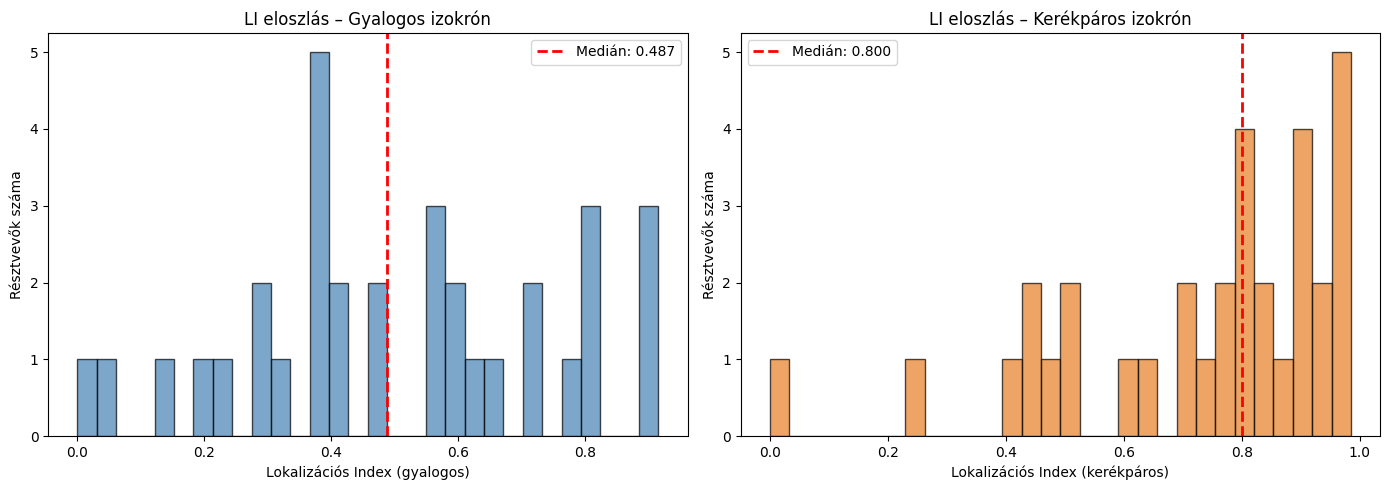

In [108]:
# ============================================================================
# FÁZIS 5.2: LOKALIZÁCIÓS INDEX (LI) SZÁMÍTÁS
# ============================================================================

def compute_localization_index(stay_points_df, isochrones_gdf, mode='walk'):
    """
    LI = (izokrónon belüli stay pointok) / (összes stay point)
    """
    iso_col = f'{mode}_iso'
    results = []

    # Stay pointok GeoDataFrame-ként
    sp_geometry = [Point(lng, lat) for lng, lat in
                   zip(stay_points_df['stay_lng'], stay_points_df['stay_lat'])]
    sp_gdf = gpd.GeoDataFrame(stay_points_df, geometry=sp_geometry, crs='EPSG:4326')

    for _, iso_row in isochrones_gdf.iterrows():
        resp_id = iso_row['respondent_id']
        iso_poly = iso_row[iso_col] if iso_col in iso_row.index else iso_row.geometry

        if iso_poly is None or (hasattr(iso_poly, 'is_empty') and iso_poly.is_empty):
            continue

        # Résztvevő stay pointjai
        resp_sp = sp_gdf[sp_gdf['respondent_id'] == resp_id]
        if len(resp_sp) == 0:
            continue

        # Hány esik az izokrónba?
        within_mask = resp_sp.within(iso_poly)
        n_within = within_mask.sum()
        n_total = len(resp_sp)
        li = n_within / n_total if n_total > 0 else 0

        results.append({
            'respondent_id': resp_id,
            f'n_sp_total': n_total,
            f'n_sp_local_{mode}': n_within,
            f'LI_{mode}': li
        })

    return pd.DataFrame(results)

if stay_points_df is not None and isochrones_gdf is not None:
    # Gyalogos LI
    li_walk = compute_localization_index(stay_points_df, isochrones_gdf, 'walk')

    # Kerékpáros LI
    li_bike = compute_localization_index(stay_points_df, isochrones_gdf, 'bike')

    # Egyesítés
    localization_df = li_walk.merge(
        li_bike[['respondent_id', 'n_sp_local_bike', 'LI_bike']],
        on='respondent_id', how='left'
    )

    print("LOKALIZÁCIÓS INDEX STATISZTIKÁK:")
    print("=" * 60)
    for mode in ['walk', 'bike']:
        col = f'LI_{mode}'
        vals = localization_df[col].dropna()
        print(f"\n  {mode.upper()} ({len(vals)} résztvevő):")
        print(f"    Medián:  {vals.median():.3f}")
        print(f"    Átlag:   {vals.mean():.3f}")
        print(f"    IQR:     [{vals.quantile(0.25):.3f}, {vals.quantile(0.75):.3f}]")
        print(f"    Min-Max: [{vals.min():.3f}, {vals.max():.3f}]")

    # Hisztogram
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.hist(localization_df['LI_walk'].dropna(), bins=30, color='steelblue',
             edgecolor='black', alpha=0.7)
    ax1.axvline(localization_df['LI_walk'].median(), color='red', linestyle='--',
                linewidth=2, label=f"Medián: {localization_df['LI_walk'].median():.3f}")
    ax1.set_xlabel('Lokalizációs Index (gyalogos)')
    ax1.set_ylabel('Résztvevők száma')
    ax1.set_title('LI eloszlás – Gyalogos izokrón')
    ax1.legend()

    ax2.hist(localization_df['LI_bike'].dropna(), bins=30, color='#e67e22',
             edgecolor='black', alpha=0.7)
    ax2.axvline(localization_df['LI_bike'].median(), color='red', linestyle='--',
                linewidth=2, label=f"Medián: {localization_df['LI_bike'].median():.3f}")
    ax2.set_xlabel('Lokalizációs Index (kerékpáros)')
    ax2.set_ylabel('Résztvevők száma')
    ax2.set_title('LI eloszlás – Kerékpáros izokrón')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('localization_index_histogram.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    localization_df = None
    print("Nincs adat.")


In [109]:
# ============================================================================
# FÁZIS 6.1: SZOCIODEMOGRÁFIAI ADATOK BETÖLTÉSE
# ============================================================================
# A kérdőíves adatok SPSS .sav formátumban állnak rendelkezésre
# (Koltai et al., 2025 adat-donációs kutatás).
# A fájl 758 résztvevő 348 változóját tartalmazza.
# ============================================================================
!pip install pyreadstat
import pyreadstat

SAV_PATH = "adatdonacio_survey_v35_szakdolgozathoz.sav"  # <-- MÓDOSÍTSD

# --- 1) Beolvasás value label-ekkel együtt -----------------------------------
survey_raw, meta = pyreadstat.read_sav(SAV_PATH)

print(f"SAV betöltve: {survey_raw.shape[0]} résztvevő, {survey_raw.shape[1]} változó")

# --- 1b) Gazdasági aktivitás változó keresése --------------------------------
# A SAV 348 változót tartalmaz; a gazdasági aktivitásra vonatkozó oszlopnév
# nem ismert előre. Az alábbi blokk kilistázza a potenciális jelölteket.
print("\n--- Gazdasági aktivitás / foglalkozás változók keresése ---")
for col in survey_raw.columns:
    col_label = meta.column_names_to_labels.get(col, '') or ''
    if any(kw in col_label.lower() for kw in [
        'foglalk', 'aktivit', 'dolgoz', 'munkaviszony', 'gazdaság',
        'economic', 'employ', 'occupation', 'aktív', 'inaktív',
        'nyugdíj', 'tanuló', 'gyes', 'gyed', 'álláskeres'
    ]) or any(kw in col.lower() for kw in [
        'gazd', 'fogl', 'mstat', 'employ', 'econ_act', 'aktiv', 'dolg', 'munka_'
    ]):
        # Value labels ha vannak
        val_labels = meta.variable_value_labels.get(col, {})
        unique_vals = survey_raw[col].dropna().unique()[:10]
        print(f"  {col:20s} | {col_label[:60]:60s} | értékek: {unique_vals}")
        if val_labels:
            print(f"  {'':20s} | {'címkék:':60s} | {val_labels}")

# --- MANUÁLIS BEÁLLÍTÁS -------------------------------------------------------
# Az előző blokk outputja alapján állítsd be az alábbi változókat!
# Példa: ha a változó neve 'gazd_akt' és értékei 1='dolgozik', 2='tanuló' stb.
GAZD_AKT_COL = None          # <-- IDE ÍRD A VÁLTOZÓ NEVÉT, pl. 'gazd_akt'
GAZD_AKT_LABELS = None       # <-- None = automatikus (meta value labels-ből)
# Ha a fenti keresés nem talált semmit, próbáld meg manuálisan:
# print(meta.column_names_to_labels)  # összes változó listázása
# Ha a változó megvan, a bináris csoportosítás:
#   'dolgozó' = azok, akiknek van aktív munkaviszonyuk
#   'nem_dolgozó' = tanuló, nyugdíjas, GYES/GYED, álláskereső, egyéb inaktív
# A pontos mapping a value labels-től függ, az alábbi dict-et kell kitölteni:
GAZD_AKT_DOLGOZIK = []       # <-- Azon value label-ek, amelyek aktív dolgozót jelölnek

# --- 2) Releváns oszlopok kiválasztása és átnevezés --------------------------
base_cols = ['user_id_A', 'nem', 'kor', 'kor6', 'vegz', 'telep3', 'suly']
if GAZD_AKT_COL is not None and GAZD_AKT_COL in survey_raw.columns:
    base_cols.append(GAZD_AKT_COL)
    print(f"\nGazdasági aktivitás változó beállítva: '{GAZD_AKT_COL}'")
else:
    print(f"\nFIGYELEM: Gazdasági aktivitás változó nincs beállítva (GAZD_AKT_COL = {GAZD_AKT_COL}).")
    print("Állítsd be a fenti blokk alapján, majd futtasd újra!")

survey_df = survey_raw[base_cols].copy()

survey_df = survey_df.rename(columns={
    'user_id_A':  'respondent_id',
    'kor6':       'korcsoport',
    'vegz':       'iskolai_vegzettseg',
    'telep3':     'telepules_tipus',
})

# --- 3) Értékcímkék alkalmazása (olvasható kategóriák) -----------------------
NEM_LABELS = {1.0: 'férfi', 2.0: 'nő'}
KOR_LABELS = {
    1.0: '16–29', 2.0: '30–39', 3.0: '40–49',
    4.0: '50–59', 5.0: '60–69', 6.0: '70+'
}
VEGZ_LABELS = {1.0: 'alapfokú', 2.0: 'középfokú', 3.0: 'felsőfokú'}
TELEP_LABELS = {1.0: 'Budapest', 2.0: 'város', 3.0: 'falu'}

survey_df['nem'] = survey_df['nem'].map(NEM_LABELS)
survey_df['korcsoport'] = survey_df['korcsoport'].map(KOR_LABELS)
survey_df['iskolai_vegzettseg'] = survey_df['iskolai_vegzettseg'].map(VEGZ_LABELS)
survey_df['telepules_tipus'] = survey_df['telepules_tipus'].map(TELEP_LABELS)

# Gazdasági aktivitás címkézése
if GAZD_AKT_COL is not None and GAZD_AKT_COL in survey_df.columns:
    survey_df = survey_df.rename(columns={GAZD_AKT_COL: 'gazdasagi_aktivitas'})
    # Értékcímkék alkalmazása
    if GAZD_AKT_LABELS is None:
        # Automatikus: meta value labels
        val_labels = meta.variable_value_labels.get(GAZD_AKT_COL, {})
        if val_labels:
            survey_df['gazdasagi_aktivitas'] = survey_df['gazdasagi_aktivitas'].map(val_labels)
            print(f"\nGazdasági aktivitás címkék (auto): {val_labels}")
    else:
        survey_df['gazdasagi_aktivitas'] = survey_df['gazdasagi_aktivitas'].map(GAZD_AKT_LABELS)

    # Bináris dolgozik/nem_dolgozik változó
    if GAZD_AKT_DOLGOZIK:
        survey_df['dolgozik'] = survey_df['gazdasagi_aktivitas'].isin(GAZD_AKT_DOLGOZIK)
        print(f"\n  'dolgozik' = True ha gazdasági aktivitás ∈ {GAZD_AKT_DOLGOZIK}")
        print(f"  Dolgozik: {survey_df['dolgozik'].sum()}, nem dolgozik: {(~survey_df['dolgozik']).sum()}")

# respondent_id int-re konvertálás (a notebook többi részével konzisztens)
survey_df['respondent_id'] = survey_df['respondent_id'].astype(int)

print(f"\nKiválasztott oszlopok: {list(survey_df.columns)}")
print(f"Kérdőív szerinti Budapest alminta: "
      f"{(survey_df['telepules_tipus'] == 'Budapest').sum()} fő")

# --- 4) Budapest szűrés: pusztán térbeli GPS-alapon (éjszakai ping minimum nélkül) ---
if budapest_respondents:
    n_before = len(survey_df)
    survey_df = survey_df[survey_df['respondent_id'].isin(budapest_respondents)].copy()
    print(f"\nBudapest szűrés (GPS térbeli): {n_before} → {len(survey_df)} résztvevő")
    print(f"  Ebből kérdőív szerint is 'Budapest': "
          f"{(survey_df['telepules_tipus'] == 'Budapest').sum()} fő "
          f"({(survey_df['telepules_tipus'] == 'Budapest').sum() / len(survey_df) * 100:.1f}%)")
else:
    print("\nFIGYELEM: budapest_respondents nem elérhető, Budapest szűrés kihagyva.")

# --- 5) Demográfiai összefoglaló (dolgozat 3. fejezet) -----------------------
print("\n" + "=" * 60)
print("MINTA DEMOGRÁFIAI ÖSSZETÉTELE (GPS-Budapest résztvevők)")
print("=" * 60)
print(f"\nRésztvevők (GPS alapján Budapesten): {len(survey_df)} fő "
      f"(teljes minta: {len(survey_raw)})")

demo_cols = [('nem', 'Nem'), ('korcsoport', 'Korcsoport'),
             ('iskolai_vegzettseg', 'Iskolai végzettség')]
if 'gazdasagi_aktivitas' in survey_df.columns:
    demo_cols.append(('gazdasagi_aktivitas', 'Gazdasági aktivitás'))

for col, label in demo_cols:
    print(f"\n  {label}:")
    vc = survey_df[col].value_counts(dropna=False).sort_index()
    for cat, n in vc.items():
        print(f"    {cat}: {n} ({n/len(survey_df)*100:.1f}%)")

# --- 6) Egyesítés a lokalizációs index adatokkal ----------------------------
if localization_df is not None:
    analysis_df = localization_df.merge(survey_df, on='respondent_id', how='left')
    matched = analysis_df['nem'].notna().sum()
    print(f"\nEgyesítve LI adatokkal: {len(analysis_df)} résztvevő, "
          f"ebből demográfiai adat elérhető: {matched}")
else:
    analysis_df = None
    print("\nFIGYELEM: localization_df nem elérhető, csak a survey_df áll rendelkezésre.")


Defaulting to user installation because normal site-packages is not writeable
SAV betöltve: 758 résztvevő, 348 változó

--- Gazdasági aktivitás / foglalkozás változók keresése ---
  SM6A_14              | Ön milyen gyakran teszi a következőket a Facebookon? / Cikke | értékek: [6. 2. 4. 1. 3. 5. 7. 9.]
                       | címkék:                                                      | {-9999.0: 'Nincs adat', 1.0: 'Naponta többször', 2.0: 'Körülbelül naponta egyszer', 3.0: 'Heti 3-6 napon', 4.0: 'Heti 1-2 napon', 5.0: 'Néhány hetente', 6.0: 'Ritkábban', 7.0: 'Soha', 9.0: 'Nem tudom / nem válaszolok'}
  SM6B_14              | Ön milyen gyakran teszi a következőket a Facebookon? / Cikke | értékek: [3. 1. 6. 2. 5. 4. 7. 9.]
                       | címkék:                                                      | {-9999.0: 'Nincs adat', 1.0: 'Naponta többször', 2.0: 'Körülbelül naponta egyszer', 3.0: 'Heti 3-6 napon', 4.0: 'Heti 1-2 napon', 5.0: 'Néhány hetente', 6.0: 'Ritkábban', 7.0: 'So

In [78]:
# ============================================================================
# FÁZIS 6.1: SZOCIODEMOGRÁFIAI ADATOK BETÖLTÉSE
# ============================================================================
# A kérdőíves adatok SPSS .sav formátumban állnak rendelkezésre
# (Koltai et al., 2025 adat-donációs kutatás).
# A fájl 758 résztvevő 348 változóját tartalmazza.
# ============================================================================
!pip install pyreadstat
import pyreadstat

SAV_PATH = "adatdonacio_survey_v35_szakdolgozathoz.sav"  # <-- MÓDOSÍTSD

# --- 1) Beolvasás value label-ekkel együtt -----------------------------------
survey_raw, meta = pyreadstat.read_sav(SAV_PATH)

print(f"SAV betöltve: {survey_raw.shape[0]} résztvevő, {survey_raw.shape[1]} változó")

# --- 2) Releváns oszlopok kiválasztása és átnevezés --------------------------
# A notebook respondent_id-t használ; a SAV-ban ez user_id_A.
# Demográfiai változók:
#   nem    → 1='férfi', 2='nő'           (oszlopnév marad 'nem')
#   kor    → életkor (folytonos)          (oszlopnév marad 'kor')
#   kor6   → 1='16-29' … 6='70+'         → 'korcsoport'
#   vegz   → 1='alap', 2='közép', 3='felső' → 'iskolai_vegzettseg'
#   telep3 → 1='Budapest', 2='város', 3='falu' → 'telepules_tipus'
#   suly   → iteratív arányos illesztéssel számolt súly

survey_df = survey_raw[[
    'user_id_A', 'nem', 'kor', 'kor6', 'vegz', 'telep3', 'suly'
]].copy()

survey_df = survey_df.rename(columns={
    'user_id_A':  'respondent_id',
    'kor6':       'korcsoport',
    'vegz':       'iskolai_vegzettseg',
    'telep3':     'telepules_tipus',
})

# --- 3) Értékcímkék alkalmazása (olvasható kategóriák) -----------------------
NEM_LABELS = {1.0: 'férfi', 2.0: 'nő'}
KOR_LABELS = {
    1.0: '16–29', 2.0: '30–39', 3.0: '40–49',
    4.0: '50–59', 5.0: '60–69', 6.0: '70+'
}
VEGZ_LABELS = {1.0: 'alapfokú', 2.0: 'középfokú', 3.0: 'felsőfokú'}
TELEP_LABELS = {1.0: 'Budapest', 2.0: 'város', 3.0: 'falu'}

survey_df['nem'] = survey_df['nem'].map(NEM_LABELS)
survey_df['korcsoport'] = survey_df['korcsoport'].map(KOR_LABELS)
survey_df['iskolai_vegzettseg'] = survey_df['iskolai_vegzettseg'].map(VEGZ_LABELS)
survey_df['telepules_tipus'] = survey_df['telepules_tipus'].map(TELEP_LABELS)

# respondent_id int-re konvertálás (a notebook többi részével konzisztens)
survey_df['respondent_id'] = survey_df['respondent_id'].astype(int)

print(f"\nKiválasztott oszlopok: {list(survey_df.columns)}")
print(f"Kérdőív szerinti Budapest alminta: "
      f"{(survey_df['telepules_tipus'] == 'Budapest').sum()} fő")

# --- 4) Budapest szűrés: pusztán térbeli GPS-alapon (éjszakai ping minimum nélkül) ---
# A demográfiai leírás a teljes budapesti mintára vonatkozik.
# Az éjszakai ping minimum csak az elemzési alpopulációhoz szükséges (később).
# budapest_respondents: cell 1.4-ben, a night-ping szűrés ELŐTT mentett ID-k.
if budapest_respondents:
    n_before = len(survey_df)
    survey_df = survey_df[survey_df['respondent_id'].isin(budapest_respondents)].copy()
    print(f"\nBudapest szűrés (GPS térbeli): {n_before} → {len(survey_df)} résztvevő")
    print(f"  Ebből kérdőív szerint is 'Budapest': "
          f"{(survey_df['telepules_tipus'] == 'Budapest').sum()} fő "
          f"({(survey_df['telepules_tipus'] == 'Budapest').sum() / len(survey_df) * 100:.1f}%)")
else:
    print("\nFIGYELEM: budapest_respondents nem elérhető, Budapest szűrés kihagyva.")

# --- 5) Demográfiai összefoglaló (dolgozat 3. fejezet) -----------------------
# survey_df itt már csak GPS-Budapest résztvevőket tartalmaz.
print("\n" + "=" * 60)
print("MINTA DEMOGRÁFIAI ÖSSZETÉTELE (GPS-Budapest résztvevők)")
print("=" * 60)
print(f"\nRésztvevők (GPS alapján Budapesten): {len(survey_df)} fő "
      f"(teljes minta: {len(survey_raw)})")

for col, label in [('nem', 'Nem'), ('korcsoport', 'Korcsoport'),
                   ('iskolai_vegzettseg', 'Iskolai végzettség')]:
    print(f"\n  {label}:")
    vc = survey_df[col].value_counts(dropna=False).sort_index()
    for cat, n in vc.items():
        print(f"    {cat}: {n} ({n/len(survey_df)*100:.1f}%)")

# --- 6) Egyesítés a lokalizációs index adatokkal ----------------------------
if localization_df is not None:
    analysis_df = localization_df.merge(survey_df, on='respondent_id', how='left')
    matched = analysis_df['nem'].notna().sum()
    print(f"\nEgyesítve LI adatokkal: {len(analysis_df)} résztvevő, "
          f"ebből demográfiai adat elérhető: {matched}")
else:
    analysis_df = None
    print("\nFIGYELEM: localization_df nem elérhető, csak a survey_df áll rendelkezésre.")

     

Defaulting to user installation because normal site-packages is not writeable
SAV betöltve: 758 résztvevő, 348 változó

Kiválasztott oszlopok: ['respondent_id', 'nem', 'kor', 'korcsoport', 'iskolai_vegzettseg', 'telepules_tipus', 'suly']
Kérdőív szerinti Budapest alminta: 168 fő

Budapest szűrés (GPS térbeli): 758 → 311 résztvevő
  Ebből kérdőív szerint is 'Budapest': 88 fő (28.3%)

MINTA DEMOGRÁFIAI ÖSSZETÉTELE (GPS-Budapest résztvevők)

Résztvevők (GPS alapján Budapesten): 311 fő (teljes minta: 758)

  Nem:
    férfi: 134 (43.1%)
    nő: 177 (56.9%)

  Korcsoport:
    16–29: 64 (20.6%)
    30–39: 87 (28.0%)
    40–49: 80 (25.7%)
    50–59: 38 (12.2%)
    60–69: 33 (10.6%)
    70+: 9 (2.9%)

  Iskolai végzettség:
    alapfokú: 47 (15.1%)
    felsőfokú: 128 (41.2%)
    középfokú: 136 (43.7%)

Egyesítve LI adatokkal: 35 résztvevő, ebből demográfiai adat elérhető: 35


SZOCIODEMOGRÁFIAI BONTÁS – LOKALIZÁCIÓS INDEX

  Gyalogos LI × nem (2 csoport):
    férfi: n=16, medián=0.562
    nő: n=17, medián=0.459
    Mann-Whitney U = 124.0, p = 0.6787

  Gyalogos LI × korcsoport (6 csoport):
    16–29: n=3, medián=0.720
    30–39: n=4, medián=0.700
    40–49: n=10, medián=0.401
    50–59: n=6, medián=0.421
    60–69: n=6, medián=0.499
    70+: n=4, medián=0.589
    Kruskal-Wallis H = 3.32, p = 0.6502
    Bonferroni-korrigált p = 1.0000 (15 összehasonlítás)

  Gyalogos LI × iskolai_vegzettseg (3 csoport):
    alapfokú: n=4, medián=0.774
    felsőfokú: n=15, medián=0.410
    középfokú: n=14, medián=0.506
    Kruskal-Wallis H = 2.31, p = 0.3148
    Bonferroni-korrigált p = 0.9443 (3 összehasonlítás)


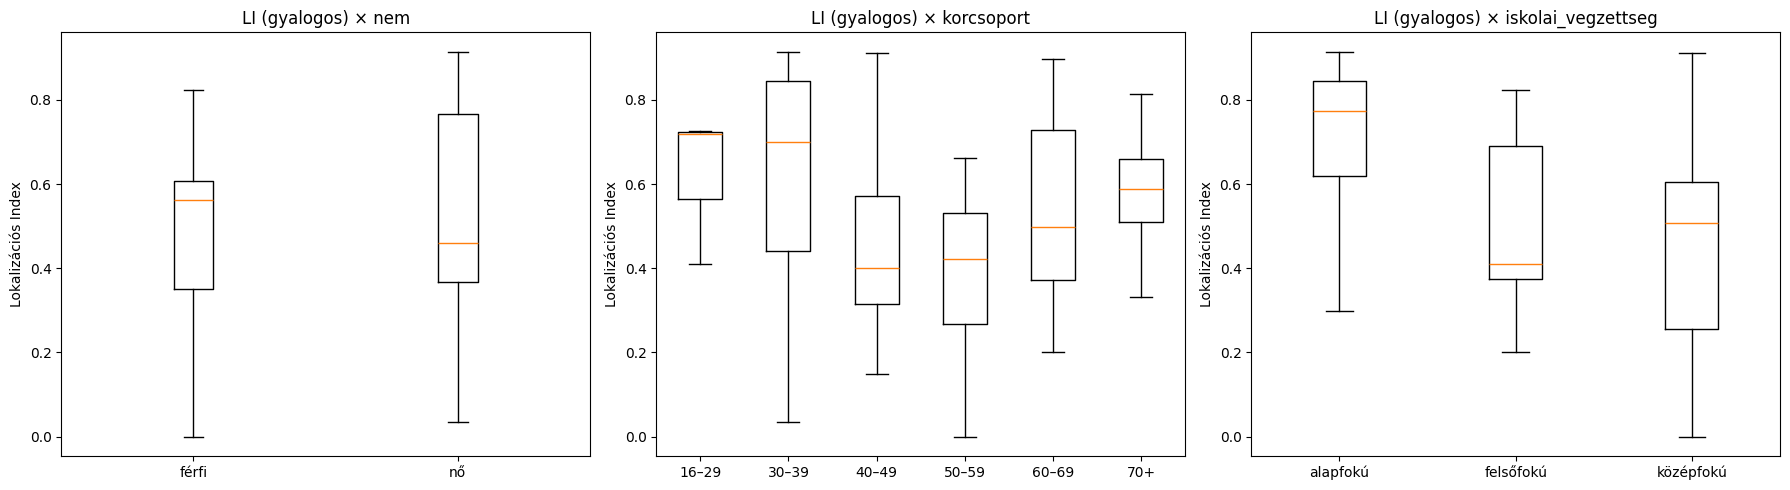

SZOCIODEMOGRÁFIAI BONTÁS – LOKALIZÁCIÓS INDEX

  Kerékpáros LI × nem (2 csoport):
    férfi: n=16, medián=0.799
    nő: n=17, medián=0.833
    Mann-Whitney U = 122.0, p = 0.6268

  Kerékpáros LI × korcsoport (6 csoport):
    16–29: n=3, medián=0.908
    30–39: n=4, medián=0.894
    40–49: n=10, medián=0.675
    50–59: n=6, medián=0.804
    60–69: n=6, medián=0.817
    70+: n=4, medián=0.798
    Kruskal-Wallis H = 4.74, p = 0.4485
    Bonferroni-korrigált p = 1.0000 (15 összehasonlítás)

  Kerékpáros LI × iskolai_vegzettseg (3 csoport):
    alapfokú: n=4, medián=0.923
    felsőfokú: n=15, medián=0.777
    középfokú: n=14, medián=0.798
    Kruskal-Wallis H = 3.14, p = 0.2075
    Bonferroni-korrigált p = 0.6226 (3 összehasonlítás)


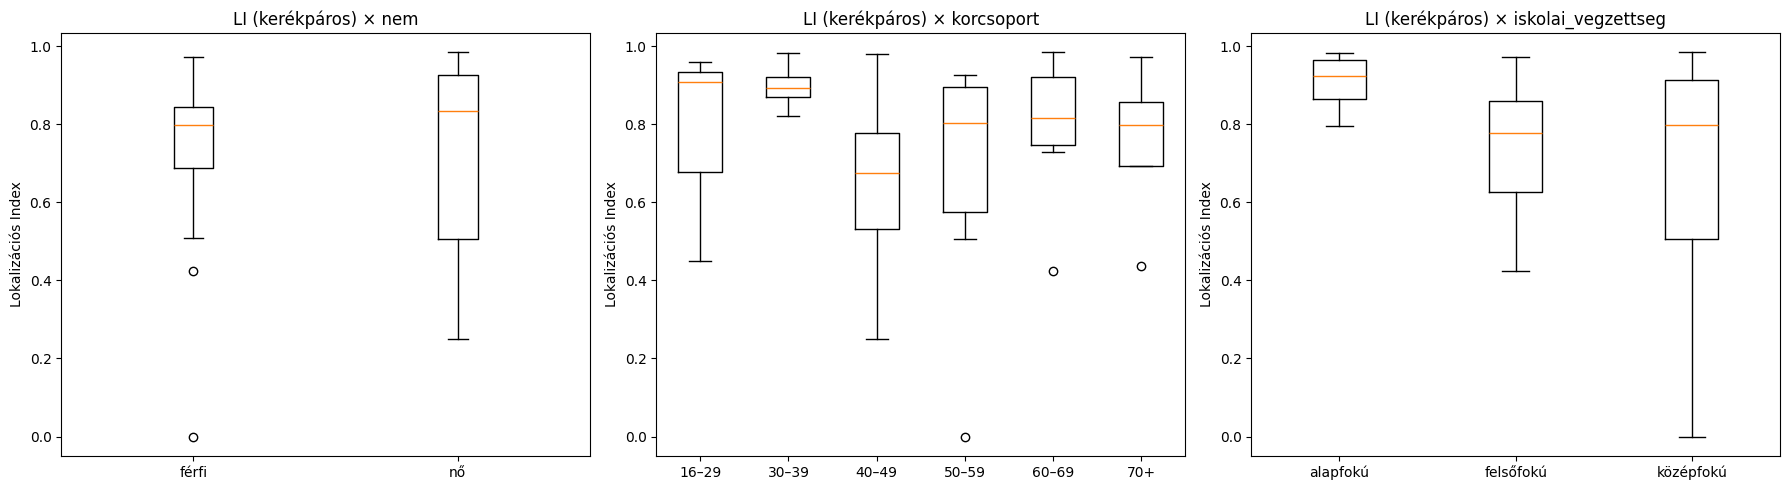

In [113]:
# ============================================================================
# FÁZIS 6.2: LI SZOCIODEMOGRÁFIAI BONTÁSA
# ============================================================================

def run_group_comparison(df, li_col, group_col, group_name):
    """Nemparaméteres csoportösszehasonlítás LI értékekre."""
    groups = df.dropna(subset=[li_col, group_col]).groupby(group_col)[li_col].apply(list)

    if len(groups) < 2:
        print(f"  {group_name}: kevesebb mint 2 csoport, teszt kihagyva")
        return

    print(f"\n  {group_name} ({len(groups)} csoport):")
    for name, vals in groups.items():
        print(f"    {name}: n={len(vals)}, medián={np.median(vals):.3f}")

    if len(groups) == 2:
        # Mann-Whitney U
        g1, g2 = list(groups)
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        print(f"    Mann-Whitney U = {stat:.1f}, p = {p:.4f}")
    else:
        # Kruskal-Wallis
        stat, p = kruskal(*groups)
        print(f"    Kruskal-Wallis H = {stat:.2f}, p = {p:.4f}")


        # Bonferroni-korrekció
        n_comparisons = len(groups) * (len(groups) - 1) // 2
        p_bonf = min(p * n_comparisons, 1.0)
        print(f"    Bonferroni-korrigált p = {p_bonf:.4f} ({n_comparisons} összehasonlítás)")

if analysis_df is not None:
    print("SZOCIODEMOGRÁFIAI BONTÁS – LOKALIZÁCIÓS INDEX")
    print("=" * 60)

    # Ellenőrzés: milyen demográfiai oszlopok állnak rendelkezésre
    demo_cols = {
        'nem': ['nem', 'gender', 'sex'],
        'korcsoport': ['korcsoport', 'age_group', 'age_category', 'kor'],
        'iskolai_vegzettseg': ['iskolai_vegzettseg', 'education', 'edu', 'vegzettseg']
    }

    for demo_name, possible_cols in demo_cols.items():
        found_col = None
        for col in possible_cols:
            if col in analysis_df.columns:
                found_col = col
                break

        if found_col:
            run_group_comparison(analysis_df, 'LI_walk', found_col, f"Gyalogos LI × {demo_name}")
        else:
            print(f"\n  {demo_name}: oszlop nem található ({possible_cols})")

    # Boxplot vizualizáció
    avail_demo = []
    for demo_name, possible_cols in demo_cols.items():
        for col in possible_cols:
            if col in analysis_df.columns:
                avail_demo.append((demo_name, col))
                break

    if avail_demo:
        fig, axes = plt.subplots(1, len(avail_demo), figsize=(6 * len(avail_demo), 5))
        if len(avail_demo) == 1:
            axes = [axes]

        for ax, (demo_name, col) in zip(axes, avail_demo):
            data = analysis_df.dropna(subset=['LI_walk', col])
            groups = sorted(data[col].unique())
            box_data = [data[data[col] == g]['LI_walk'].values for g in groups]
            ax.boxplot(box_data, labels=groups)
            ax.set_title(f'LI (gyalogos) × {demo_name}')
            ax.set_ylabel('Lokalizációs Index')

        plt.tight_layout()
        plt.savefig('li_demographic_boxplots.png', dpi=200, bbox_inches='tight')
        plt.show()
else:
    print("Nincs adat a szociodemográfiai elemzéshez.")


# ============================================================================
# FÁZIS 6.2: LI SZOCIODEMOGRÁFIAI BONTÁSA
# ============================================================================

def run_group_comparison(df, li_col, group_col, group_name):
    """Nemparaméteres csoportösszehasonlítás LI értékekre."""
    groups = df.dropna(subset=[li_col, group_col]).groupby(group_col)[li_col].apply(list)

    if len(groups) < 2:
        print(f"  {group_name}: kevesebb mint 2 csoport, teszt kihagyva")
        return

    print(f"\n  {group_name} ({len(groups)} csoport):")
    for name, vals in groups.items():
        print(f"    {name}: n={len(vals)}, medián={np.median(vals):.3f}")

    if len(groups) == 2:
        # Mann-Whitney U
        g1, g2 = list(groups)
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        print(f"    Mann-Whitney U = {stat:.1f}, p = {p:.4f}")
    else:
        # Kruskal-Wallis
        stat, p = kruskal(*groups)
        print(f"    Kruskal-Wallis H = {stat:.2f}, p = {p:.4f}")


        # Bonferroni-korrekció
        n_comparisons = len(groups) * (len(groups) - 1) // 2
        p_bonf = min(p * n_comparisons, 1.0)
        print(f"    Bonferroni-korrigált p = {p_bonf:.4f} ({n_comparisons} összehasonlítás)")

if analysis_df is not None:
    print("SZOCIODEMOGRÁFIAI BONTÁS – LOKALIZÁCIÓS INDEX")
    print("=" * 60)

    # Ellenőrzés: milyen demográfiai oszlopok állnak rendelkezésre
    demo_cols = {
        'nem': ['nem', 'gender', 'sex'],
        'korcsoport': ['korcsoport', 'age_group', 'age_category', 'kor'],
        'iskolai_vegzettseg': ['iskolai_vegzettseg', 'education', 'edu', 'vegzettseg']
    }

    for demo_name, possible_cols in demo_cols.items():
        found_col = None
        for col in possible_cols:
            if col in analysis_df.columns:
                found_col = col
                break

        if found_col:
            run_group_comparison(analysis_df, 'LI_bike', found_col, f"Kerékpáros LI × {demo_name}")
        else:
            print(f"\n  {demo_name}: oszlop nem található ({possible_cols})")

    # Boxplot vizualizáció
    avail_demo = []
    for demo_name, possible_cols in demo_cols.items():
        for col in possible_cols:
            if col in analysis_df.columns:
                avail_demo.append((demo_name, col))
                break

    if avail_demo:
        fig, axes = plt.subplots(1, len(avail_demo), figsize=(6 * len(avail_demo), 5))
        if len(avail_demo) == 1:
            axes = [axes]

        for ax, (demo_name, col) in zip(axes, avail_demo):
            data = analysis_df.dropna(subset=['LI_bike', col])
            groups = sorted(data[col].unique())
            box_data = [data[data[col] == g]['LI_bike'].values for g in groups]
            ax.boxplot(box_data, labels=groups)
            ax.set_title(f'LI (kerékpáros) × {demo_name}')
            ax.set_ylabel('Lokalizációs Index')

        plt.tight_layout()
        plt.savefig('li_demographic_boxplots_bike.png', dpi=200, bbox_inches='tight')
        plt.show()
else:
    print("Nincs adat a szociodemográfiai elemzéshez.")


POI-SŰRŰSÉG ↔ LOKALIZÁCIÓS INDEX KORRELÁCIÓ:
  Össz POI-sűrűség (gyalog) ↔ LI: rho=0.292, p=0.0986

  Kategóriánkénti (gyalogos):
    kereskedelem............. rho= 0.187  p=0.2985 
    egeszsegugy.............. rho= 0.221  p=0.2162 
    oktatas.................. rho= 0.433  p=0.0118 *
    szabadido................ rho= 0.327  p=0.0634 
    kozszolgaltatasok........ rho= 0.179  p=0.3182 


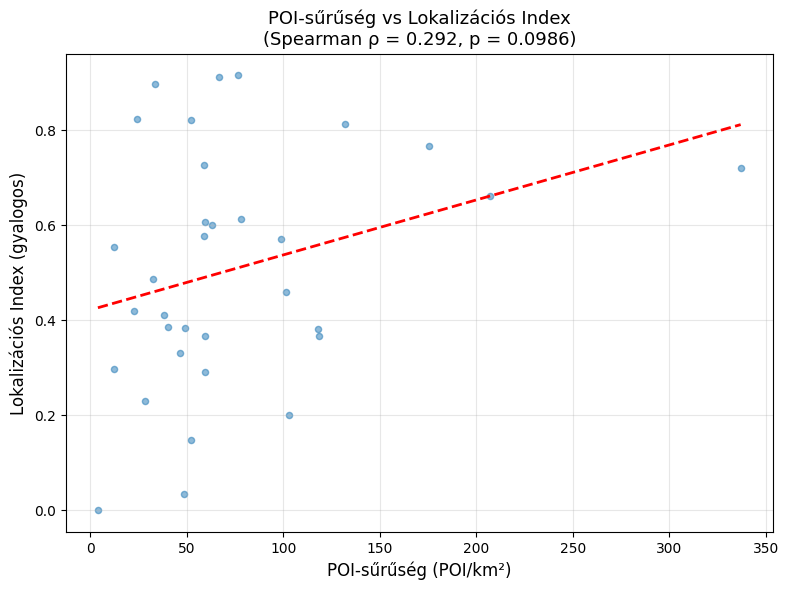

In [111]:
# ============================================================================
# FÁZIS 6.3: POI-SŰRŰSÉG VS LOKALIZÁCIÓS INDEX KORRELÁCIÓ
# ============================================================================

if localization_df is not None and accessibility_df is not None:
    corr_df = localization_df.merge(accessibility_df, on='respondent_id')

    print("POI-SŰRŰSÉG ↔ LOKALIZÁCIÓS INDEX KORRELÁCIÓ:")
    print("=" * 60)

    moreno_cats = ['kereskedelem', 'egeszsegugy', 'oktatas', 'szabadido', 'kozszolgaltatasok']

    # Össz POI-sűrűség vs LI
    if 'walk_density' in corr_df.columns:
        valid = corr_df.dropna(subset=['walk_density', 'LI_walk'])
        rho, p = spearmanr(valid['walk_density'], valid['LI_walk'])
        print(f"  Össz POI-sűrűség (gyalog) ↔ LI: rho={rho:.3f}, p={p:.4f}")

    # Kategóriánkénti korreláció
    print(f"\n  Kategóriánkénti (gyalogos):")
    for cat in moreno_cats:
        col = f'walk_{cat}'
        if col in corr_df.columns:
            valid = corr_df.dropna(subset=[col, 'LI_walk'])
            if len(valid) > 5:
                rho, p = spearmanr(valid[col], valid['LI_walk'])
                sig = '*' if p < 0.05 else ''
                print(f"    {cat:.<25} rho={rho:>6.3f}  p={p:.4f} {sig}")

    # Scatterplot
    if 'walk_density' in corr_df.columns:
        fig, ax = plt.subplots(figsize=(8, 6))
        valid = corr_df.dropna(subset=['walk_density', 'LI_walk'])
        ax.scatter(valid['walk_density'], valid['LI_walk'], alpha=0.5, s=20)

        # Trendvonal
        z = np.polyfit(valid['walk_density'], valid['LI_walk'], 1)
        p_line = np.poly1d(z)
        x_range = np.linspace(valid['walk_density'].min(), valid['walk_density'].max(), 100)
        ax.plot(x_range, p_line(x_range), 'r--', linewidth=2)

        rho, pval = spearmanr(valid['walk_density'], valid['LI_walk'])
        ax.set_xlabel('POI-sűrűség (POI/km²)', fontsize=12)
        ax.set_ylabel('Lokalizációs Index (gyalogos)', fontsize=12)
        ax.set_title(f'POI-sűrűség vs Lokalizációs Index\n(Spearman ρ = {rho:.3f}, p = {pval:.4f})',
                     fontsize=13)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('poi_density_vs_li.png', dpi=200, bbox_inches='tight')
        plt.show()
else:
    print("Nincs adat a korrelációs elemzéshez.")


Feature mátrix: 33 résztvevő × 7 feature
  KMeans k=2: silhouette=0.294
  KMeans k=3: silhouette=0.336
  KMeans k=4: silhouette=0.250
  KMeans k=5: silhouette=0.275

Optimális k: 3 (silhouette=0.336)

KLASZTERPROFILOK:

  Klaszter 0 (n=1):
    n_unique_locations................. medián=    30.0
    mean_dist_from_home................ medián=  1671.5
    std_dist_from_home................. medián=  3880.0
    max_dist_from_home................. medián= 18632.4
    median_duration_min................ medián=  1567.6
    weekday_ratio...................... medián=     1.0
    LI_walk............................ medián=     0.8

  Klaszter 1 (n=26):
    n_unique_locations................. medián=  1942.0
    mean_dist_from_home................ medián=  1931.2
    std_dist_from_home................. medián=  2704.9
    max_dist_from_home................. medián= 15473.4
    median_duration_min................ medián=    63.3
    weekday_ratio...................... medián=     0.8
    LI_wal

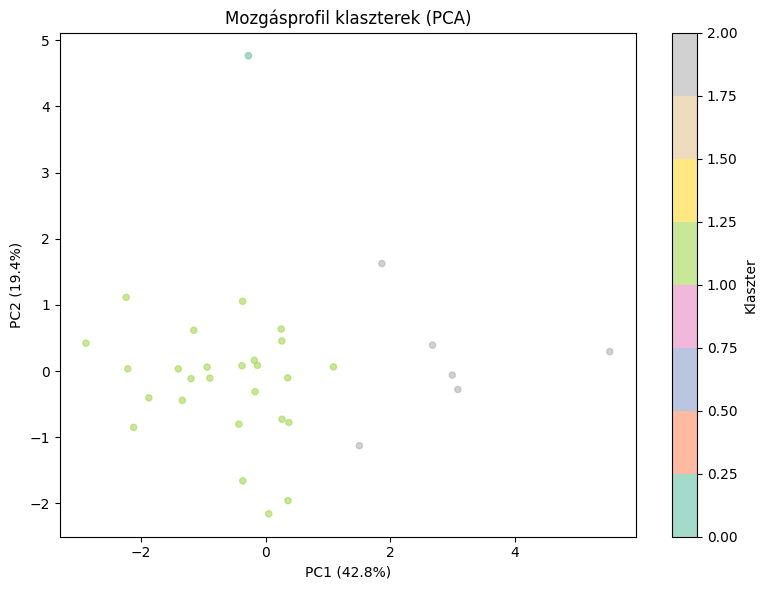

In [114]:
# ============================================================================
# FÁZIS 6.4: MOZGÁSPROFIL KLASZTEREZÉS
# ============================================================================

if stay_points_df is not None and home_work_df is not None and localization_df is not None:
    # Feature engineering résztvevőnként
    features = []
    for resp_id, sp_grp in stay_points_df.groupby('respondent_id'):
        home_row = home_work_df[home_work_df['respondent_id'] == resp_id]
        if len(home_row) == 0:
            continue
        h_lat = home_row.iloc[0]['home_lat']
        h_lng = home_row.iloc[0]['home_lng']

        # Távolságok home-tól
        dists = sp_grp.apply(
            lambda r: haversine_m(h_lat, h_lng, r['stay_lat'], r['stay_lng']), axis=1
        )

        li_row = localization_df[localization_df['respondent_id'] == resp_id]
        li_walk = li_row.iloc[0]['LI_walk'] if len(li_row) > 0 else np.nan

        features.append({
            'respondent_id': resp_id,
            'n_unique_locations': len(sp_grp),
            'mean_dist_from_home': dists.mean(),
            'std_dist_from_home': dists.std(),
            'max_dist_from_home': dists.max(),
            'median_duration_min': sp_grp['duration_min'].median(),
            'weekday_ratio': (sp_grp['day_of_week'] < 5).mean(),
            'LI_walk': li_walk
        })

    features_df = pd.DataFrame(features).dropna()
    print(f"Feature mátrix: {features_df.shape[0]} résztvevő × {features_df.shape[1]-1} feature")

    # Standardizálás
    feature_cols = ['n_unique_locations', 'mean_dist_from_home', 'std_dist_from_home',
                    'max_dist_from_home', 'median_duration_min', 'weekday_ratio', 'LI_walk']
    X = StandardScaler().fit_transform(features_df[feature_cols])

    # KMeans: optimális k keresése (silhouette)
    sil_scores = {}
    for k in range(2, 6):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sil = silhouette_score(X, labels)
        sil_scores[k] = sil
        print(f"  KMeans k={k}: silhouette={sil:.3f}")

    best_k = max(sil_scores, key=sil_scores.get)
    print(f"\nOptimális k: {best_k} (silhouette={sil_scores[best_k]:.3f})")

    # Végső klaszterezés
    km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    features_df['cluster'] = km_final.fit_predict(X)

    # Klaszterprofilok
    print(f"\nKLASZTERPROFILOK:")
    print("=" * 80)
    for cl in sorted(features_df['cluster'].unique()):
        cl_data = features_df[features_df['cluster'] == cl]
        print(f"\n  Klaszter {cl} (n={len(cl_data)}):")
        for col in feature_cols:
            print(f"    {col:.<35} medián={cl_data[col].median():>8.1f}")

    # PCA vizualizáció
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=features_df['cluster'],
                         cmap='Set2', alpha=0.6, s=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('Mozgásprofil klaszterek (PCA)')
    plt.colorbar(scatter, label='Klaszter')
    plt.tight_layout()
    plt.savefig('movement_clusters_pca.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    features_df = None
    print("Nincs adat a klaszterezéshez.")


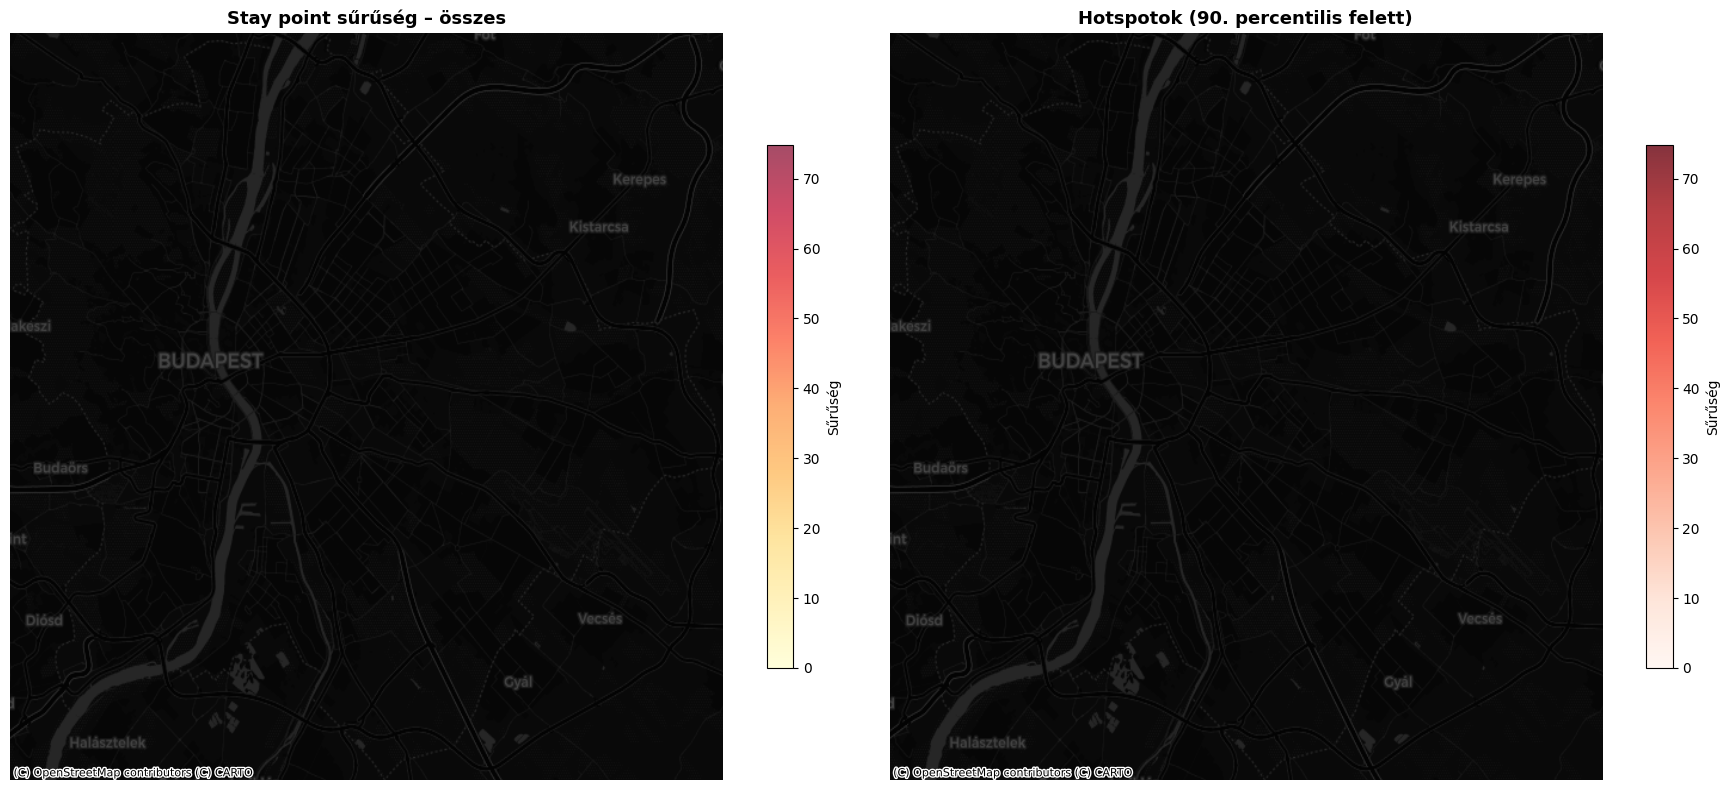

In [115]:
# ============================================================================
# FÁZIS 7.1: KDE ÉS HOTSPOT ELEMZÉS
# ============================================================================

if stay_points_df is not None and isochrones_gdf is not None:
    # Budapest bounding box
    budapest = ox.geocode_to_gdf('Budapest, Hungary')
    bounds = budapest.total_bounds  # [minx, miny, maxx, maxy]

    # KDE rácsméret
    grid_size = 200  # pixels
    x_edges = np.linspace(bounds[0], bounds[2], grid_size)
    y_edges = np.linspace(bounds[1], bounds[3], grid_size)

    # Stay point koordináták
    sp_x = stay_points_df['stay_lng'].values
    sp_y = stay_points_df['stay_lat'].values

    # 2D hisztogram
    H, xedges, yedges = np.histogram2d(sp_x, sp_y, bins=[x_edges, y_edges])
    H_smooth = gaussian_filter(H.T, sigma=3)

    # Vizualizáció
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # (a) Összes stay point KDE
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

    # Basemap-ra vetítés
    extent_3857 = [
        *transformer.transform(bounds[0], bounds[1]),
        *transformer.transform(bounds[2], bounds[3])
    ]

    im1 = axes[0].imshow(H_smooth, origin='lower',
                         extent=[extent_3857[0], extent_3857[2], extent_3857[1], extent_3857[3]],
                         cmap='YlOrRd', alpha=0.7, aspect='auto')
    ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.DarkMatter)
    axes[0].set_title('Stay point sűrűség – összes', fontsize=13, fontweight='bold')
    axes[0].set_axis_off()
    plt.colorbar(im1, ax=axes[0], label='Sűrűség', shrink=0.7)

    # (b) Hotspotok (90. percentilis felett)
    threshold = np.percentile(H_smooth[H_smooth > 0], 90)
    H_hotspot = np.where(H_smooth >= threshold, H_smooth, 0)

    im2 = axes[1].imshow(H_hotspot, origin='lower',
                         extent=[extent_3857[0], extent_3857[2], extent_3857[1], extent_3857[3]],
                         cmap='Reds', alpha=0.8, aspect='auto')
    ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.DarkMatter)
    axes[1].set_title('Hotspotok (90. percentilis felett)', fontsize=13, fontweight='bold')
    axes[1].set_axis_off()
    plt.colorbar(im2, ax=axes[1], label='Sűrűség', shrink=0.7)

    plt.tight_layout()
    plt.savefig('kde_hotspot_analysis.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print("Nincs adat a KDE elemzéshez.")


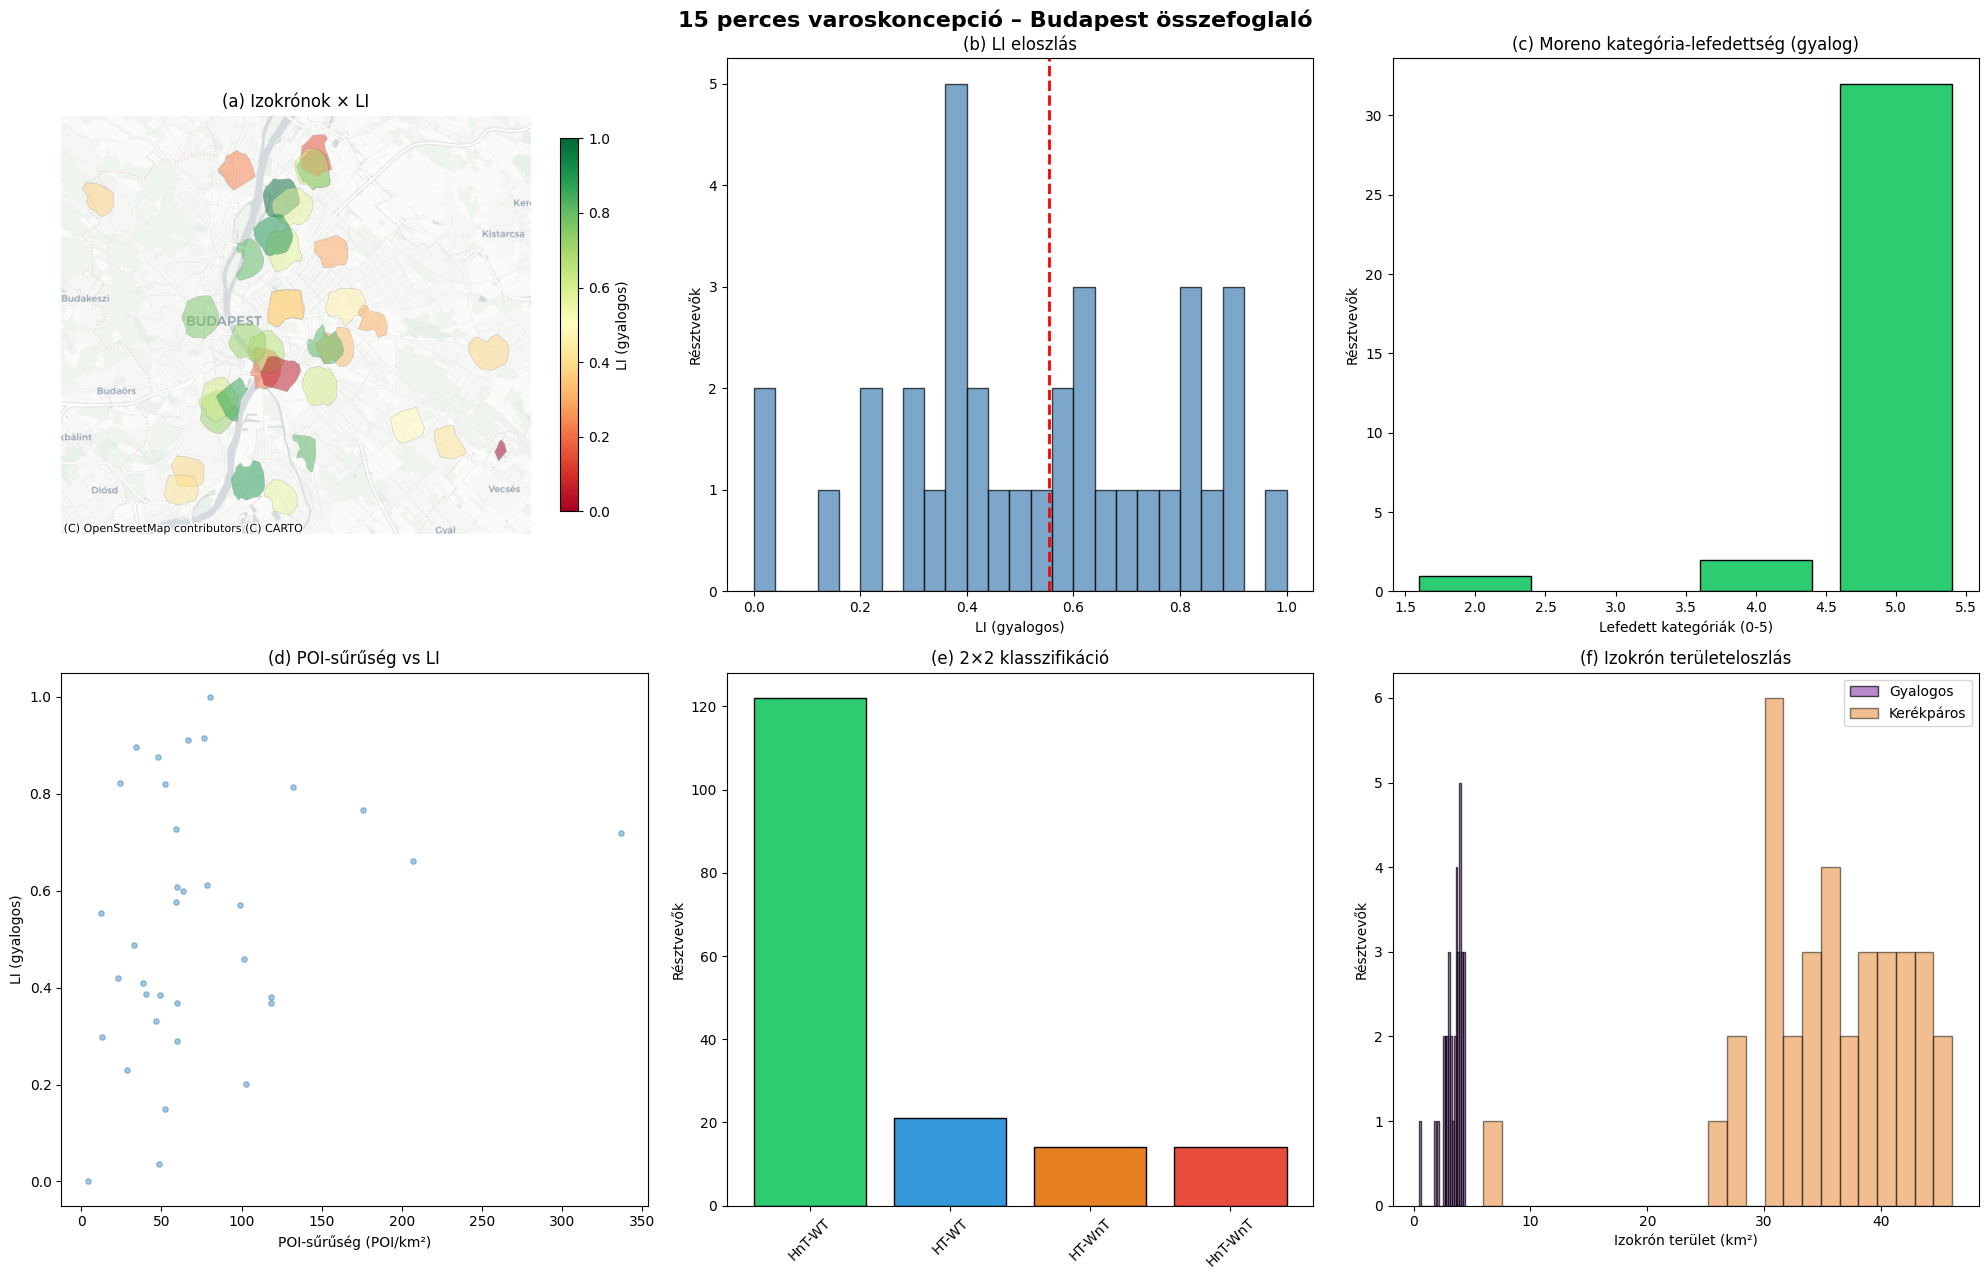

Dashboard mentve: dashboard_summary.png


In [57]:
# ============================================================================
# FÁZIS 7.2: ÖSSZEFOGLALÓ DASHBOARD
# ============================================================================

if (localization_df is not None and accessibility_df is not None
        and isochrones_gdf is not None and home_work_df is not None):

    fig, axes = plt.subplots(2, 3, figsize=(20, 13))
    fig.suptitle('15 perces varoskoncepció – Budapest összefoglaló', fontsize=16, fontweight='bold')

    # (a) Izokrón térkép LI színezéssel
    ax = axes[0, 0]
    iso_li = isochrones_gdf.merge(localization_df[['respondent_id', 'LI_walk']], on='respondent_id')
    iso_li_web = iso_li.to_crs(epsg=3857)
    iso_li_web.plot(ax=ax, column='LI_walk', cmap='RdYlGn', alpha=0.5, edgecolor='gray',
                    linewidth=0.3, legend=True,
                    legend_kwds={'label': 'LI (gyalogos)', 'shrink': 0.7})
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
    ax.set_title('(a) Izokrónok × LI')
    ax.set_axis_off()

    # (b) LI eloszlás
    ax = axes[0, 1]
    ax.hist(localization_df['LI_walk'].dropna(), bins=25, color='steelblue',
            edgecolor='black', alpha=0.7)
    ax.axvline(localization_df['LI_walk'].median(), color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('LI (gyalogos)')
    ax.set_ylabel('Résztvevők')
    ax.set_title('(b) LI eloszlás')

    # (c) Kategória-lefedettség
    ax = axes[0, 2]
    if 'walk_cov' in accessibility_df.columns:
        cov_counts = accessibility_df['walk_cov'].value_counts().sort_index()
        ax.bar(cov_counts.index, cov_counts.values, color='#2ecc71', edgecolor='black')
        ax.set_xlabel('Lefedett kategóriák (0-5)')
        ax.set_ylabel('Résztvevők')
        ax.set_title('(c) Moreno kategória-lefedettség (gyalog)')

    # (d) POI-sűrűség vs LI
    ax = axes[1, 0]
    if accessibility_df is not None and 'walk_density' in accessibility_df.columns:
        corr = localization_df.merge(accessibility_df[['respondent_id', 'walk_density']], on='respondent_id')
        valid = corr.dropna(subset=['walk_density', 'LI_walk'])
        ax.scatter(valid['walk_density'], valid['LI_walk'], alpha=0.4, s=15)
        ax.set_xlabel('POI-sűrűség (POI/km²)')
        ax.set_ylabel('LI (gyalogos)')
        ax.set_title('(d) POI-sűrűség vs LI')

    # (e) 2×2 klasszifikáció
    ax = axes[1, 1]
    if participant_classification is not None:
        cat_counts = participant_classification['category'].value_counts()
        colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
        ax.bar(cat_counts.index, cat_counts.values, color=colors[:len(cat_counts)], edgecolor='black')
        ax.set_ylabel('Résztvevők')
        ax.set_title('(e) 2×2 klasszifikáció')
        ax.tick_params(axis='x', rotation=45)

    # (f) Izokrón terület-eloszlás
    ax = axes[1, 2]
    if 'walk_area_km2' in isochrones_gdf.columns:
        ax.hist(isochrones_gdf['walk_area_km2'].dropna(), bins=25, color='#9b59b6',
                edgecolor='black', alpha=0.7, label='Gyalogos')
        if 'bike_area_km2' in isochrones_gdf.columns:
            ax.hist(isochrones_gdf['bike_area_km2'].dropna(), bins=25, color='#e67e22',
                    edgecolor='black', alpha=0.5, label='Kerékpáros')
        ax.set_xlabel('Izokrón terület (km²)')
        ax.set_ylabel('Résztvevők')
        ax.set_title('(f) Izokrón területeloszlás')
        ax.legend()

    plt.tight_layout()
    plt.savefig('dashboard_summary.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("Dashboard mentve: dashboard_summary.png")
else:
    print("Nem áll rendelkezésre elegendő adat az összefoglaló dashboardhoz.")


In [116]:
# ============================================================================
# FÁZIS 7.3: EREDMÉNYEK EXPORTÁLÁSA
# ============================================================================

output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

exports = {
    'home_work_df': home_work_df,
    'accessibility_df': accessibility_df,
    'localization_df': localization_df,
    'stay_points_df': stay_points_df,
    'participant_classification': participant_classification
}

for name, df in exports.items():
    if df is not None:
        path = output_dir / f'{name}.csv'
        df.to_csv(path, index=False)
        print(f"  ✓ {name} → {path} ({len(df)} sor)")
    else:
        print(f"  ✗ {name}: nincs adat")

# GeoJSON exportok
if isochrones_gdf is not None:
    iso_path = output_dir / 'isochrones.geojson'
    isochrones_gdf.to_file(iso_path, driver='GeoJSON')
    print(f"  ✓ isochrones → {iso_path}")

if 'pois_gdf' in dir() and pois_gdf is not None and len(pois_gdf) > 0:
    poi_path = output_dir / 'budapest_moreno_pois.geojson'
    pois_gdf.to_file(poi_path, driver='GeoJSON')
    print(f"  ✓ POI-k → {poi_path}")

print("\n" + "=" * 60)
print("ELEMZÉS BEFEJEZVE")
print("=" * 60)

# Összesítő
if localization_df is not None:
    n_ht = len(localization_df)
    li_med = localization_df['LI_walk'].median()
    print(f"  Elemzett résztvevők (HT): {n_ht}")
    print(f"  Lokalizációs Index medián (gyalogos): {li_med:.3f}")
if participant_classification is not None:
    print(f"\n  Klasszifikáció:")
    for cat, count in participant_classification['category'].value_counts().items():
        print(f"    {cat}: {count}")


  ✓ home_work_df → results/home_work_df.csv (148 sor)
  ✓ accessibility_df → results/accessibility_df.csv (33 sor)
  ✓ localization_df → results/localization_df.csv (33 sor)
  ✓ stay_points_df → results/stay_points_df.csv (71149 sor)
  ✓ participant_classification → results/participant_classification.csv (148 sor)
  ✓ isochrones → results/isochrones.geojson
  ✓ POI-k → results/budapest_moreno_pois.geojson

ELEMZÉS BEFEJEZVE
  Elemzett résztvevők (HT): 33
  Lokalizációs Index medián (gyalogos): 0.487

  Klasszifikáció:
    HnT-WT: 104
    HT-WT: 21
    HT-WnT: 12
    HnT-WnT: 11
